In [1]:
import os, sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, accuracy_score, average_precision_score, f1_score

import joblib

In [2]:
# Define the Neural Network Model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size=1):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)  # Batch normalization
        self.dropout1 = nn.Dropout(0.3)  # Dropout to avoid overfitting

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(hidden_size3, output_size)

    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(torch.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x).squeeze(-1)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            logits = model(inputs).squeeze(-1)
            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    aupr = average_precision_score(all_labels, all_probs)
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = float('nan')  # If only one class present

    return aupr, auroc


def create_directory(dir_path):
    """
    Creates a directory if it does not exist.

    Parameters:
    dir_path (str): Path to the directory to be created.
    """
    os.makedirs(dir_path, exist_ok=True)  # Creates the directory and ignores if it exists
    print(f"Directory '{dir_path}' is ready.")


In [4]:
def concat_df_in_dir(input_direc, iter_num=20, tail='.tsv', sep_='\t'):
    # Build file name tail list to ensure the correct order
    file_tail_list = []
    for i in range(iter_num):
        file_tail = '_' + str(i) + tail
        file_tail_list.append(file_tail)

    df_list = []
    files = os.listdir(input_direc)
    for f in range(iter_num):
        file_tail = file_tail_list[f]
        for file in files:
            if file.endswith(file_tail):
                print(file)
                df = pd.read_csv(input_direc+file, sep=sep_, index_col=None)
                df_list.append(df)
    df_all = pd.concat(df_list)
    return df_all


def create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/input/",
                    giv_dir='GIV/', iter_num=10):
    df_SL = concat_df_in_dir(input_dir+giv_dir, iter_num=iter_num, tail='.tsv')
    print(df_SL.shape)
    df_SL = df_SL.reset_index().drop('index', axis=1)
    return df_SL


def recall_at_k(y_true, y_pred, K):
    '''
    Compute Recall@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - recall_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Total number of relevant items in the entire dataset
    total_relevant = np.sum(y_true)
    # Recall@K formula
    return relevant_at_k / total_relevant if total_relevant > 0 else 0.0

def precision_at_k(y_true, y_pred, K):
    '''
    Compute Precision@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - precision_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Precision@K formula
    return relevant_at_k / K if K > 0 else 0.0


def plot_ROC_PR(all_labels, all_probs, plt_direc='./ROC_PR_curves.pdf', K=10):
    # Generate ROC and PR curves
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    # Calculate AUC for ROC and PR
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    print(f'ROC AUC: {roc_auc:.4f}')
    print(f'PRC AUC: {pr_auc:.4f}')
    print(f"Average Precision: {average_precision:.4f}")

    # Calculate Precision@K and Recall@K
    recall_k = recall_at_k(all_labels, all_probs, K)
    precision_k = precision_at_k(all_labels, all_probs, K)
    print(f"Recall@{K}: {recall_k:.4f}")
    print(f"Precision@{K}: {precision_k:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()
    plt.close()
    return [roc_auc, pr_auc, average_precision, recall_k, precision_k]


In [5]:
# Function to log messages with timestamp
def log_message(message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{timestamp}] {message}")


def split_train_val_test_cv(df, label_col, non_feature_cols, query_col='Query', lib_col='Gene',
                            test_ratio=0.2, val_ratio=0.1, rand_seed=42, cv=1, k=1):
    features = df.drop(columns=non_feature_cols)#.values
    #labels = df[label_col]#.values
    #print(label_col)

    # Remove NAs
    features.dropna(axis=0, how='any', inplace=True)
    #labels = labels.loc[features.index]
    #print(features.shape)

    if cv == 1:
        df_sub = df.loc[features.index]

        # First, split into train (70%) and temp (30%)
        train_df, temp_df = train_test_split(df_sub, test_size=(test_ratio+val_ratio), stratify=df_sub[label_col], random_state=rand_seed)

        # Split temp into validation (10%) and test (20%) maintaining the ratio
        val_size = val_ratio / (val_ratio + test_ratio)  # Adjusted split size
        val_df, test_df = train_test_split(temp_df, test_size=(1 - val_size), stratify=temp_df[label_col], random_state=rand_seed)

        # Print the sizes
        print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")
        print("Final test:train ratio:", len(test_df)/(len(train_df)+len(val_df)))

        # Extract X and y from the datasets
        X_train = train_df.drop(columns=non_feature_cols)
        y_train = train_df[label_col]

        X_val = val_df.drop(columns=non_feature_cols)
        y_val = val_df[label_col]

        X_test = test_df.drop(columns=non_feature_cols)
        y_test = test_df[label_col]
        
    elif cv == 2:
        # Split the data into train, val, and test sets by holding out query only
        df_sub = df.loc[features.index, [query_col]]
        labels = df.loc[features.index, label_col]

        query_genes = df_sub[query_col].unique()
        print(len(query_genes), "of unique queries in total")
        test_len = int(len(query_genes)*test_ratio)
        val_len = int(len(query_genes)*val_ratio)

        # Random sample from query genes
        np.random.seed(rand_seed)
        test_query = np.random.choice(query_genes, size=test_len, replace=False, p=None)
        train_query = list(set(query_genes)-set(test_query))
        val_query = np.random.choice(train_query, size=val_len, replace=False, p=None)
        train_query = list(set(train_query)-set(val_query))
        print(len(val_query), "queries held out for validation set")
        print(len(test_query), "queries held out for test set")

        train_idx = df_sub[df_sub[query_col].isin(train_query)].index
        val_idx = df_sub[df_sub[query_col].isin(val_query)].index
        test_idx = df_sub[df_sub[query_col].isin(test_query)].index

        X_train = features.loc[train_idx]
        X_val = features.loc[val_idx]
        X_test = features.loc[test_idx]
        y_train = labels.loc[train_idx]
        y_val = labels.loc[val_idx]
        y_test = labels.loc[test_idx]
        print(X_train.shape)
        print(X_val.shape)
        print(X_test.shape)
        print("Final test ratio of pairs:", X_test.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0]))
        print("Final test:train ratio", X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]))
    
    elif cv == 3:
        df_sub = df.loc[features.index, [query_col, lib_col, label_col]]
        labels = df_sub[label_col]

        # Code adapted from MLEC-iSL
        # https://github.com/kunjiefan/MLEC-iSL/blob/main/code/utils.py
        SL_potential_score = df.loc[features.index].groupby(query_col).agg({label_col:"sum"}).reset_index()
        SL_potential_score.columns = ["gene", "num_SL_partner"]
        #random_seed=5959
        training_percent = 1 - test_ratio - val_ratio
        val_percent = val_ratio

        # split into train, val and test
        print("spliting data into train, validation and test...")
        # gene-level split: genes in train, val and test are different
        num_samples = SL_potential_score.shape[0]
        all_idx = list(range(num_samples))
        np.random.seed(rand_seed)
        np.random.shuffle(all_idx)

        SL_potential_train = SL_potential_score.iloc[all_idx[:int(num_samples*training_percent)]]
        SL_potential_val = SL_potential_score.iloc[all_idx[int(num_samples*training_percent):int(num_samples*(training_percent+val_percent))]]
        SL_potential_test = SL_potential_score.iloc[all_idx[int(num_samples*(training_percent+val_percent)):]]

        # generate SL pair data
        training_genes = SL_potential_train["gene"].values
        val_genes = SL_potential_val["gene"].values
        test_genes = SL_potential_test["gene"].values
        # make training and test data balanced (X)
        SL_pair_train = df_sub[(df_sub[query_col].isin(training_genes))&(df_sub[lib_col].isin(training_genes))]
        SL_pair_val = df_sub[(df_sub[query_col].isin(val_genes))&(df_sub[lib_col].isin(val_genes))]
        SL_pair_test = df_sub[(df_sub[query_col].isin(test_genes))&(df_sub[lib_col].isin(test_genes))]

        # Note: Here they did 1:1 PNR, but we can comment for now and keep the origianl PNR
        SL_pair_train_pos = SL_pair_train[SL_pair_train[label_col]==1]
        SL_pair_train_neg = SL_pair_train[SL_pair_train[label_col]==0]#.sample(n=SL_pair_train_pos.shape[0])
        SL_pair_train = pd.concat([SL_pair_train_pos, SL_pair_train_neg])
        SL_pair_val_pos = SL_pair_val[SL_pair_val[label_col]==1]
        SL_pair_val_neg = SL_pair_val[SL_pair_val[label_col]==0]#.sample(n=SL_pair_val_pos.shape[0])
        SL_pair_val = pd.concat([SL_pair_val_pos, SL_pair_val_neg])
        SL_pair_test_pos = SL_pair_test[SL_pair_test[label_col]==1]
        SL_pair_test_neg = SL_pair_test[SL_pair_test[label_col]==0]#.sample(n=SL_pair_test_pos.shape[0])
        SL_pair_test = pd.concat([SL_pair_test_pos, SL_pair_test_neg])

        X_train = features.loc[SL_pair_train.index]
        X_val = features.loc[SL_pair_val.index]
        X_test = features.loc[SL_pair_test.index]
        y_train = labels.loc[SL_pair_train.index]
        y_val = labels.loc[SL_pair_val.index]
        y_test = labels.loc[SL_pair_test.index]
        print(X_train.shape)
        print(X_val.shape)
        print(X_test.shape)
        print("Final test ratio of pairs:", X_test.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0]))
        print("Final test:train ratio", X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]))
        #print("Excluded pairs:", features.shape[0] - X_train.shape[0] - X_test.shape[0])
    elif cv == 4: # CV2, but 10 folds iteration
        # Split the data into train, val, and test sets by 10-fold query gene splitting
        df_sub = df.loc[features.index, [query_col]]
        labels = df.loc[features.index, label_col]

        query_genes = np.array(sorted(df_sub[query_col].unique()))
        print(len(query_genes), "unique queries in total")

        # Shuffle query genes reproducibly
        rng = np.random.default_rng(rand_seed)
        rng.shuffle(query_genes)

        # Create 10 folds
        folds = np.array_split(query_genes, 10)

        # Define k here: (1-based index: k in [1,10])
        #k = 1  # example value: you can parameterize this

        # Wrap-around logic for val fold
        test_fold_idx = k - 1
        val_fold_idx = (k - 2) % 10

        test_query = folds[test_fold_idx]
        val_query = folds[val_fold_idx]
        train_query = np.concatenate(
            [folds[i] for i in range(10) if i != test_fold_idx and i != val_fold_idx]
        )

        print(len(train_query), "queries used for training set")
        print(len(val_query), "queries held out for validation set")
        print("Val queries:", val_query)
        print(len(test_query), "queries held out for test set")
        print("Test queries:", test_query)

        # Indices
        train_idx = df_sub[df_sub[query_col].isin(train_query)].index
        val_idx = df_sub[df_sub[query_col].isin(val_query)].index
        test_idx = df_sub[df_sub[query_col].isin(test_query)].index

        # Subset features and labels
        X_train = features.loc[train_idx]
        X_val = features.loc[val_idx]
        X_test = features.loc[test_idx]
        y_train = labels.loc[train_idx]
        y_val = labels.loc[val_idx]
        y_test = labels.loc[test_idx]

        print("Train set shape:", X_train.shape)
        print("Validation set shape:", X_val.shape)
        print("Test set shape:", X_test.shape)
        print("Final test ratio of pairs:", X_test.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0]))
        print("Final test:train ratio", X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]))
    else:
        return
    
    split_dict = dict()
    split_dict['X_train'] = X_train
    split_dict['X_val'] = X_val
    split_dict['X_test'] = X_test
    split_dict['y_train'] = y_train
    split_dict['y_val'] = y_val
    split_dict['y_test'] = y_test
    return split_dict

In [6]:
def plot_losses(train_losses, val_losses, train_label="Training Loss", val_label="Validation Loss", plt_direc=None):
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label=train_label, marker="o")
    plt.plot(epochs, val_losses, label=val_label, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()


In [7]:
# Training, validation, and testing function
def train_validate_test_NN(train_test_split,
                             df, non_feature_cols=['col_name'],
                             output_dir="/home/myersc/zhan6668/DepGI/data/output/",
                             plt_name='NN_SL_concat_50epochs_ROC_PR_curves1_stringent.pdf',
                             table_name='NN_test_SL_concat_50epochs_Stringent_Type1.tsv',
                             batch_size=64, num_epochs=50, learning_rate=1e-3, patience=5, decay_factor=0.1,
                             bool_save_model=True, model_name='model.pth',
                             scaler_direc=None, bool_plot_loss=False,
                             hidden_size1=512, hidden_size2=256, hidden_size3=128, topk=10):
    # Use GPU if available
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
    print(f"Using {device} device")

    # Split the data into train and test sets
    X_train = train_test_split['X_train']
    X_test = train_test_split['X_test']
    y_train = train_test_split['y_train']
    y_test = train_test_split['y_test']
    test_idx = y_test.index
    X_val = train_test_split['X_val']
    y_val = train_test_split['y_val']

    # Initialize NN model
    input_size = X_train.shape[1]
    output_size = 1  # Binary classification, 1 required by BCE loss
    model = NeuralNetwork(input_size, hidden_size1, hidden_size2, hidden_size3, output_size).to(device)

    # Standardize the training features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_val = scaler.transform(X_val)
    # Save the scaler
    if scaler_direc is not None:
        joblib.dump(scaler, output_dir+scaler_direc)

    # Convert the data into PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)#.to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)#.to(device)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)#.to(device)

    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)#.to(device)  # CrossEntropyLoss expects long for labels
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)#.to(device)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)#.to(device)

    # Create TensorDatasets and DataLoaders for batch processing
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Define loss and optimizer (using CrossEntropyLoss for classification)
    #criterion = nn.CrossEntropyLoss()
    #pos_weight = torch.tensor([555], device=device)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Add weights to pos class
    criterion = FocalLoss(alpha=0.75, gamma=1.5) # default is gamma=2.0
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Scheduler: Reduce LR when validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=decay_factor, patience=5, verbose=True)

    #best_val_loss = float('inf')
    best_aupr = float(0.0)
    epochs_no_improve = 0
    best_model_state = None

    train_losses = []
    val_losses = []

    train_auprs = []
    val_auprs = []

    # Training the model
    log_message("Training started")
    start_time = time.time()
    # Training loop with early stopping based on validation loss
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to device
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float()
                outputs = model(inputs).squeeze(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Update learning rate scheduler
        scheduler.step(val_loss)

        train_aupr, train_auroc = evaluate_metrics(model, train_loader, device)
        val_aupr, val_auroc = evaluate_metrics(model, val_loader, device)

        train_auprs.append(train_aupr)
        val_auprs.append(val_aupr)

        print(f"Epoch {epoch+1}: Train AUPR={train_aupr:.4f} AUROC={train_auroc:.4f} | Val AUPR={val_aupr:.4f} AUROC={val_auroc:.4f}")

        # Early stopping check
        #if val_loss < best_val_loss:
        #    best_val_loss = val_loss
        if val_aupr > best_aupr:
            best_aupr = val_aupr
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    # Calculate and log total run time
    end_time = time.time()
    total_run_time = end_time - start_time
    log_message(f"Total training time: {total_run_time:.2f} seconds.")

    if bool_plot_loss:
        plot_losses(train_losses, val_losses, plt_direc=output_dir+plt_name.replace('.', '_train_val_loss.'))
        plot_losses(train_auprs, val_auprs, train_label="Training AUPR", val_label="Validation AUPR",
                    plt_direc=output_dir+plt_name.replace('.', '_train_val_aupr.'))

    # Load the best model state from validation
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Save model
    if bool_save_model:
        torch.save(model, output_dir+model_name) # model.state_dict()
        #torch.save(model.state_dict(), output_dir+model_name.replace('.pth', '_state_dict.pth')) # model.state_dict()
        print("Entire model saved successfully.")

    # Testing phase: Collect predicted scores and true labels
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            # For classification, collect predicted probabilities and true labels.
            # Here we assume a binary classification with two output neurons.
            # We apply softmax and take the probability for the positive class (index 1).
            #probabilities = torch.softmax(outputs, dim=1)[:, 1]

            # Convert logits to probabilities
            probs = torch.sigmoid(outputs)

            all_scores.append(probs.cpu())
            all_labels.append(labels.cpu())

            # Compute predictions
            predicted = (probs >= 0.5).long()

            # Update counters
            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()

            # Also compute accuracy if needed
            #_, predicted = torch.max(outputs, 1)
            #total += labels.size(0)
            #correct += (predicted == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = correct / total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    
    # Concatenate all batches
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    perf_metrics = plot_ROC_PR(all_labels, all_scores, plt_direc=output_dir+plt_name, K=topk)
    print('\n------------------------\n')
    df_test = df.loc[test_idx]
    df_test = df_test[non_feature_cols]
    df_test['predict_proba'] = all_scores
    df_test.to_csv(output_dir+table_name, sep='\t')

    return model, df_test, perf_metrics


In [8]:
def optim_NN_pipeline(df_score, label_col='K_SL_n3', non_feature_cols=['feature'],
                         test_ratio=0.2, val_ratio=0.1, rand_seed=42, k_fold=1,
                         output_dir='Horlbeck2018/model_output/',
                         plt_name='Kn2_NN_SL_30epochs_ROC_PR_curves_1.pdf',
                         table_name='Kn2_NN_test_SL_30epochs_1.tsv', batch_size=64, num_epochs=30,
                         bool_save_model=True, model_name='Kn2_NN_SL_30epochs_1.pth',
                         scaler_direc=None, bool_plot_loss=True,
                         hidden_size1=512, hidden_size2=256, hidden_size3=128,
                         learning_rate=1e-3, patience=5, decay_factor=0.1,
                         cv=1, query_col='gene1', lib_col='gene2', topk=10):
    # Create a directory if it does not exist
    create_directory(output_dir)

    # Remove self-GIs:
    df = df_score[df_score[query_col]!=df_score[lib_col]]

    if cv in [1,2,3,4]:
        print(f"Data Split Method: CV{cv}")
        train_test_split = split_train_val_test_cv(df, label_col=label_col, query_col=query_col, lib_col=lib_col,
                         non_feature_cols=non_feature_cols, test_ratio=test_ratio, val_ratio=val_ratio,
                                               rand_seed=rand_seed, cv=cv, k=k_fold)
    else:
        print("Incorrect input. Please select cv=1/2/3/4.")
        return

    model, df_test, perf_metrics = train_validate_test_NN(train_test_split=train_test_split,
                              df=df, non_feature_cols=non_feature_cols,
                              output_dir=output_dir, plt_name=plt_name, table_name=table_name,
                              batch_size=batch_size, num_epochs=num_epochs,
                              learning_rate=learning_rate, patience=patience, decay_factor=decay_factor,
                              bool_save_model=bool_save_model, model_name=model_name,
                              scaler_direc=scaler_direc, bool_plot_loss=bool_plot_loss,
                              hidden_size1=hidden_size1, hidden_size2=hidden_size2, hidden_size3=hidden_size3, topk=topk)
    return model, df_test, perf_metrics


In [9]:
def filter_unique_pairs_by_lowest_FDR(df, col1='Gene', col2='Query', col_fdr='FDR'):
    # Drop rows with missing values in the relevant columns
    df = df.dropna(subset=[col1, col2, col_fdr])
    # Remove self-interactions
    idx_self = df[df[col1]==df[col2]].index
    df = df.drop(idx_self, axis=0)
    # Normalize the pairs directly into a tuple without creating a new column
    normalized_pairs = df[[col1, col2]].apply(lambda row: tuple(sorted(row)), axis=1)
    # Combine normalized pairs and column 'C' into a new DataFrame
    normalized_df = pd.DataFrame({'normalized_pair': normalized_pairs, col_fdr: df[col_fdr]})
    # Group by the normalized pair and get the index of the row with the lowest 'C' for each pair
    min_c_indices = normalized_df.groupby('normalized_pair')[col_fdr].idxmin()
    # Use these indices to filter the original DataFrame
    filtered_df = df.loc[min_c_indices]
    return filtered_df.reset_index(drop=True)

In [10]:
# Main

In [11]:
non_feature_cols = ['Gene', 'Query', 'qGI_score', 'FDR', 'GI_standard', 'GI_stringent',
                   'GI_standard_Type1', 'GI_standard_Type2', 'GI_standard_Type3',
                   'GI_stringent_Type1', 'GI_stringent_Type2', 'GI_stringent_Type3']

In [12]:
df_SL = create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/input/",
                giv_dir='GIV_24Q4/ReLU128_5L/', iter_num=20)

qGI_24Q4_GIV_ReLU128_5L_0.tsv
qGI_24Q4_GIV_ReLU128_5L_1.tsv
qGI_24Q4_GIV_ReLU128_5L_2.tsv
qGI_24Q4_GIV_ReLU128_5L_3.tsv
qGI_24Q4_GIV_ReLU128_5L_4.tsv
qGI_24Q4_GIV_ReLU128_5L_5.tsv
qGI_24Q4_GIV_ReLU128_5L_6.tsv
qGI_24Q4_GIV_ReLU128_5L_7.tsv
qGI_24Q4_GIV_ReLU128_5L_8.tsv
qGI_24Q4_GIV_ReLU128_5L_9.tsv
qGI_24Q4_GIV_ReLU128_5L_10.tsv
qGI_24Q4_GIV_ReLU128_5L_11.tsv
qGI_24Q4_GIV_ReLU128_5L_12.tsv
qGI_24Q4_GIV_ReLU128_5L_13.tsv
qGI_24Q4_GIV_ReLU128_5L_14.tsv
qGI_24Q4_GIV_ReLU128_5L_15.tsv
qGI_24Q4_GIV_ReLU128_5L_16.tsv
qGI_24Q4_GIV_ReLU128_5L_17.tsv
qGI_24Q4_GIV_ReLU128_5L_18.tsv
qGI_24Q4_GIV_ReLU128_5L_19.tsv
(3934728, 268)


In [13]:
# 12022024: Filter out ABBA duplicated pairs and only keep the one with lower FDR
df_SL = filter_unique_pairs_by_lowest_FDR(df_SL, col1='Gene', col2='Query', col_fdr='FDR')

In [14]:
df_SL

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
0,A1BG,ABCC1,0.123320,0.752717,NaN,NaN,0,0,0,0,...,4.913545,-4.577069,-2.975184,0.219520,12.293355,-4.577069,-4.577069,-4.577069,8.642893,-4.577069
1,A1BG,ACACA,0.008654,0.865827,NaN,NaN,0,0,0,0,...,4.303340,-4.555482,-2.751121,-0.054748,12.947809,-4.555482,-4.555482,-4.555482,10.567736,-4.555482
2,A1BG,ACO2,-0.033253,0.999314,NaN,NaN,0,0,0,0,...,4.548736,-4.722307,-2.503048,-1.429313,12.398306,-4.722307,-4.722307,-4.722307,11.951158,-4.722307
3,A1BG,ACTB,-0.012187,0.991106,NaN,NaN,0,0,0,0,...,8.235797,-6.877022,0.485464,-4.421445,20.778425,-6.877022,-6.877022,-6.877022,15.593998,-6.877022
4,A1BG,ACTG1,-0.004685,0.974414,NaN,NaN,0,0,0,0,...,6.541844,-6.561955,-1.588224,-4.106378,19.115791,-6.561955,-6.561955,-6.561955,12.307260,-6.561955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3912774,ZYG11A,ZDHHC5,-0.012643,0.942470,NaN,NaN,0,0,0,0,...,-0.987153,-3.426391,-0.600135,3.363746,10.479098,-3.426391,-3.426391,-3.426391,9.282865,8.296420
3912775,ZYG11B,ZDHHC5,-0.091661,0.905424,NaN,NaN,0,0,0,0,...,0.054278,-2.504334,0.321922,1.532488,6.988276,-2.504334,-2.504334,-2.504334,2.574751,-1.657835
3912776,ZYX,ZDHHC5,-0.138232,0.716525,NaN,NaN,0,0,0,0,...,5.589154,-4.271820,2.370458,-2.886664,5.771198,-4.271820,-4.271820,-4.271820,7.560047,-4.271820
3912777,ZZEF1,ZDHHC5,-0.041178,0.957260,NaN,NaN,0,0,0,0,...,0.022988,-2.610372,0.215884,2.645627,6.473591,-2.610372,-2.610372,-2.610372,3.664232,-2.610372


In [16]:
df_SL['Query'].unique().shape

(222,)

In [13]:
# CV2 on the whole data 
num_e = 50
lr = 1e-2
pt = 10
decay = 0.1
n = 10 # number of cross validations
cv = 2 # hold out query only
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f/"
prefix = "CV2_811_GIV_NN_LR1e2_50e_p10_d01"
start_i = 1

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f/' is ready.
Data Split Method: CV2
220 of unique queries in total
22 queries held out for validation set
22 queries held out for test set
(2997506, 256)
(374711, 256)
(374643, 256)
Final test ratio of pairs: 0.09998852372386478
Final test:train ratio 0.11109918333976346
Using cuda device
[2025-07-04 11:03:09] Training started
Epoch 1/50: Train Loss: 0.0040, Val Loss: 0.0053
Epoch 1: Train AUPR=0.0110 AUROC=0.8404 | Val AUPR=0.0219 AUROC=0.8498
Epoch 2/50: Train Loss: 0.0038, Val Loss: 0.0050
Epoch 2: Train AUPR=0.0193 AUROC=0.8548 | Val AUPR=0.0288 AUROC=0.8564
Epoch 3/50: Train Loss: 0.0037, Val Loss: 0.0052
Epoch 3: Train AUPR=0.0190 AUROC=0.8582 | Val AUPR=0.0194 AUROC=0.8526
Epoch 4/50: Train Loss: 0.0037, Val Loss: 0.0049
Epoch 4: Train AUPR=0.0200 AUROC=0.8639 | Val AUPR=0.0174 AUROC=0.8526
Epoch 5/50: Train Loss: 0.0037, Val Loss: 0.0051
Epoch 5: Train AUPR=0.0211 AUROC=0.8670 | Val AUPR=0.0284 AU

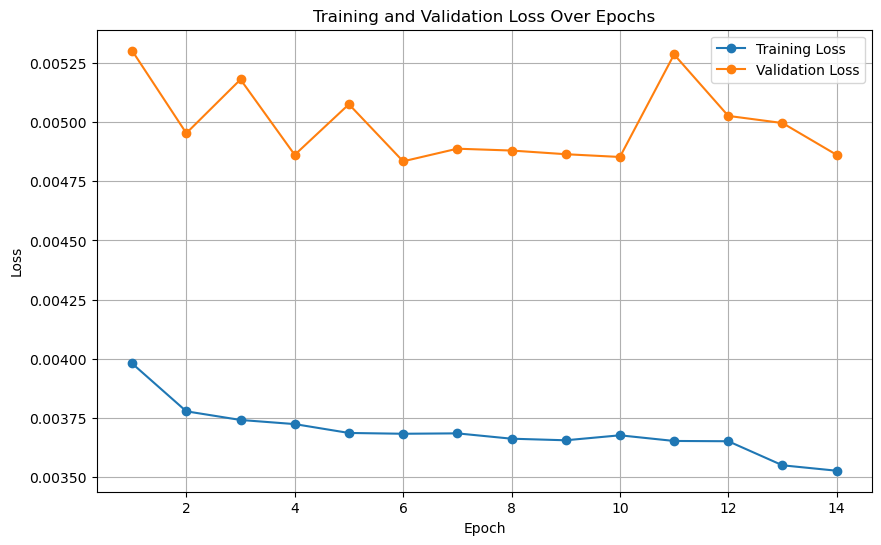

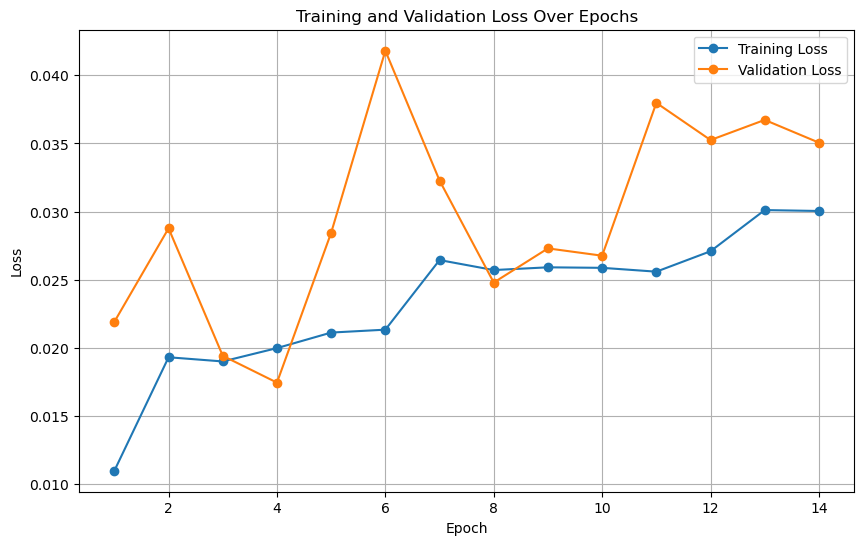

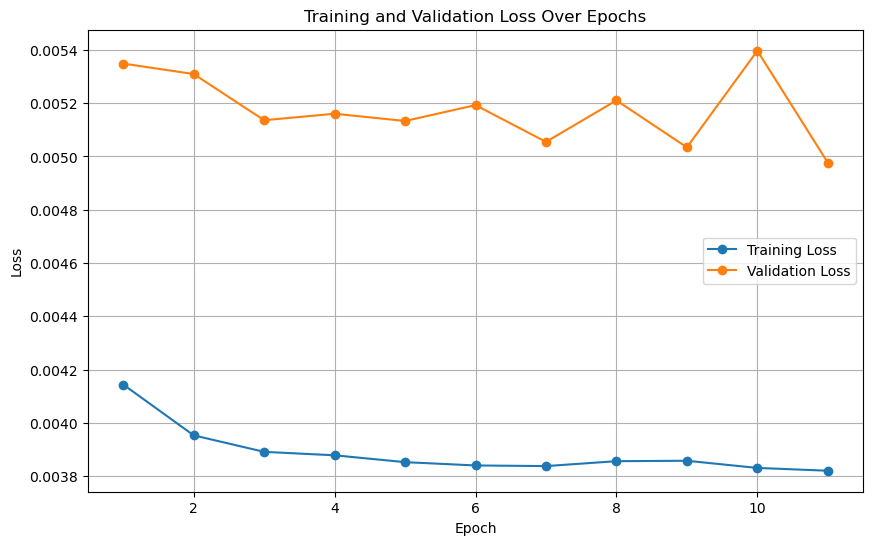

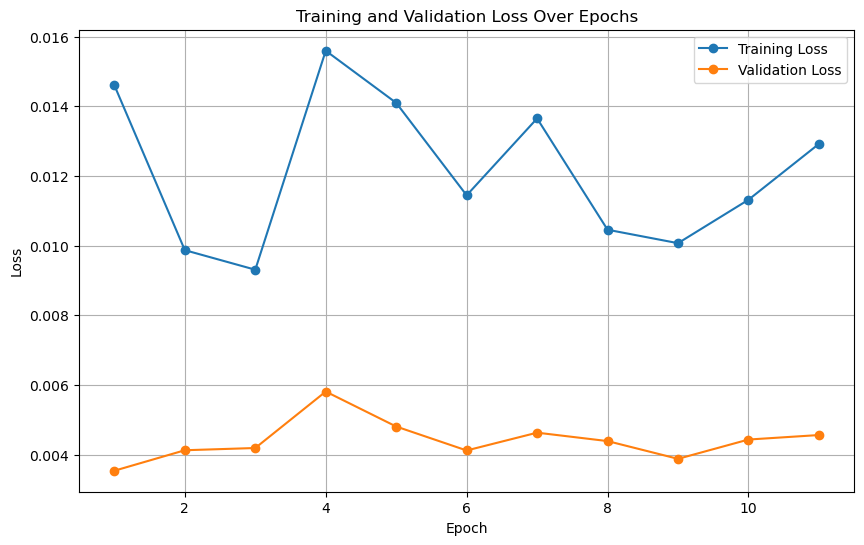

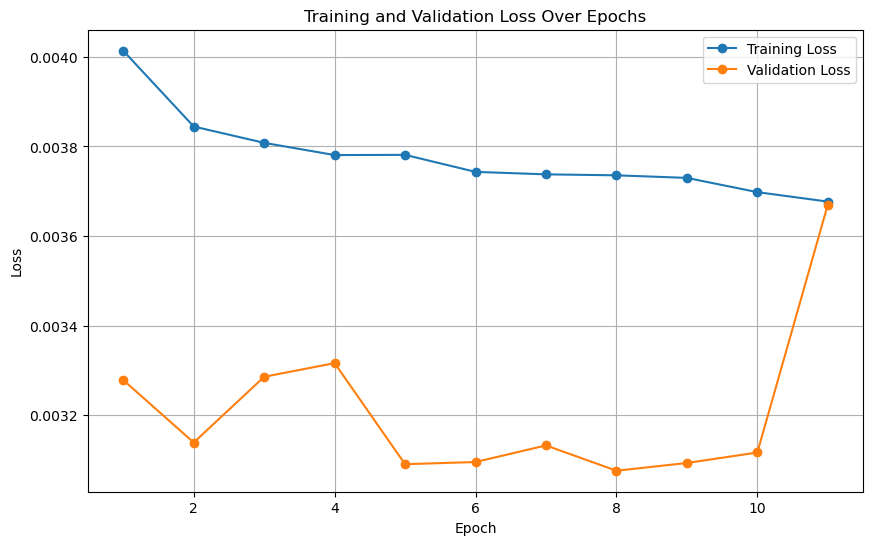

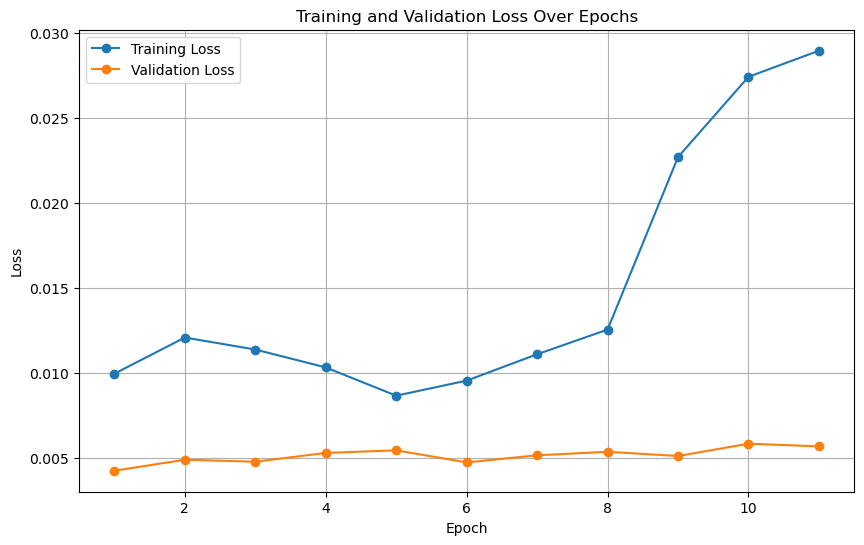

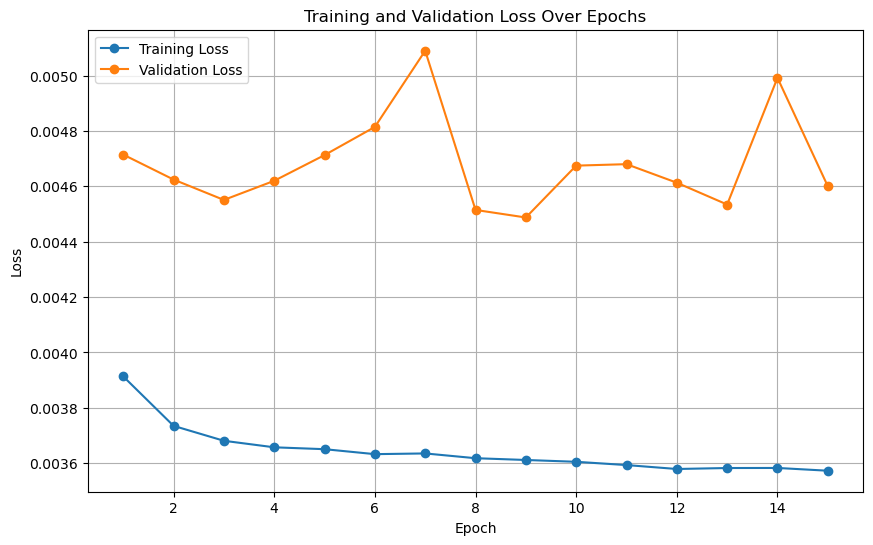

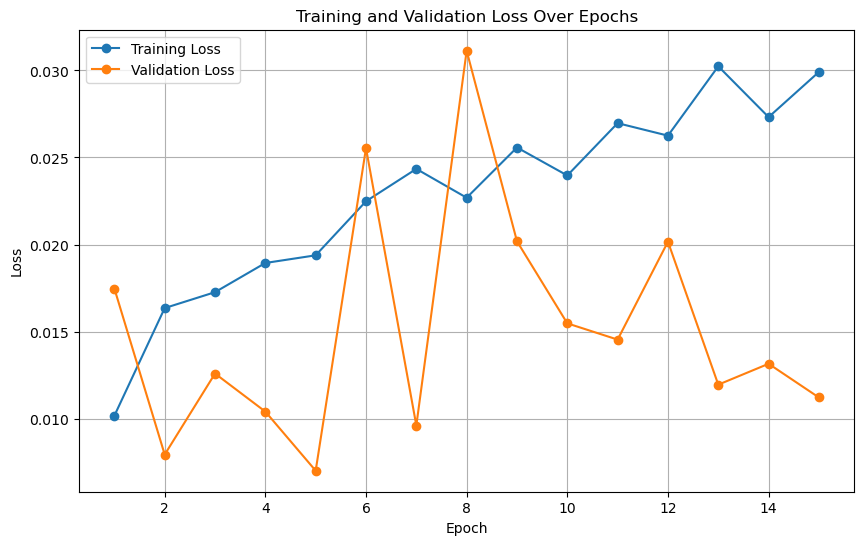

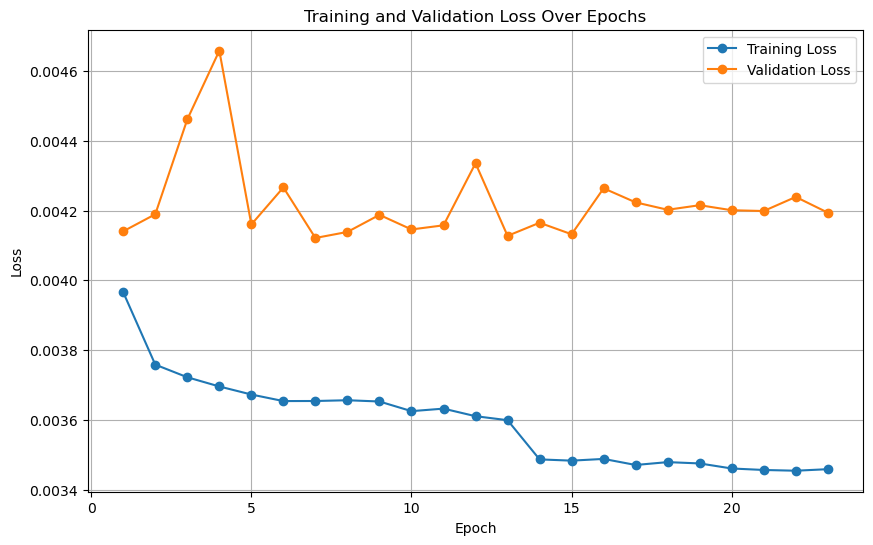

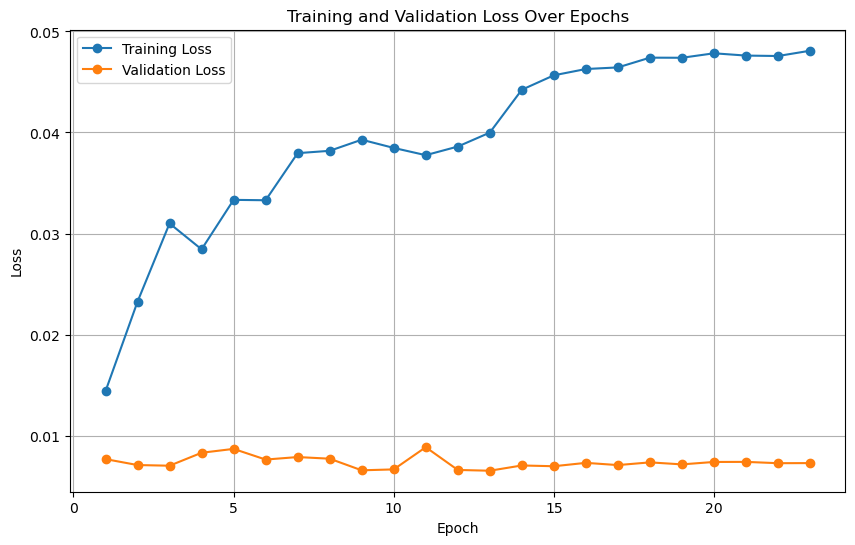

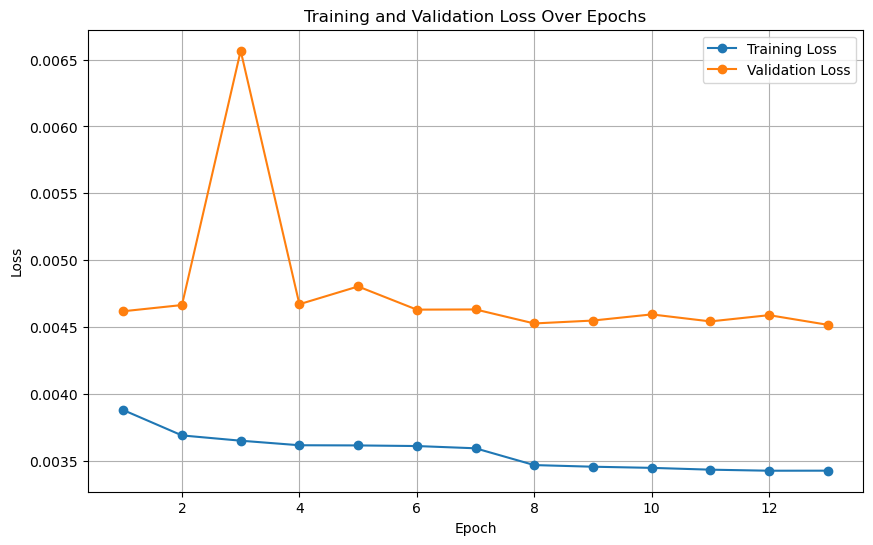

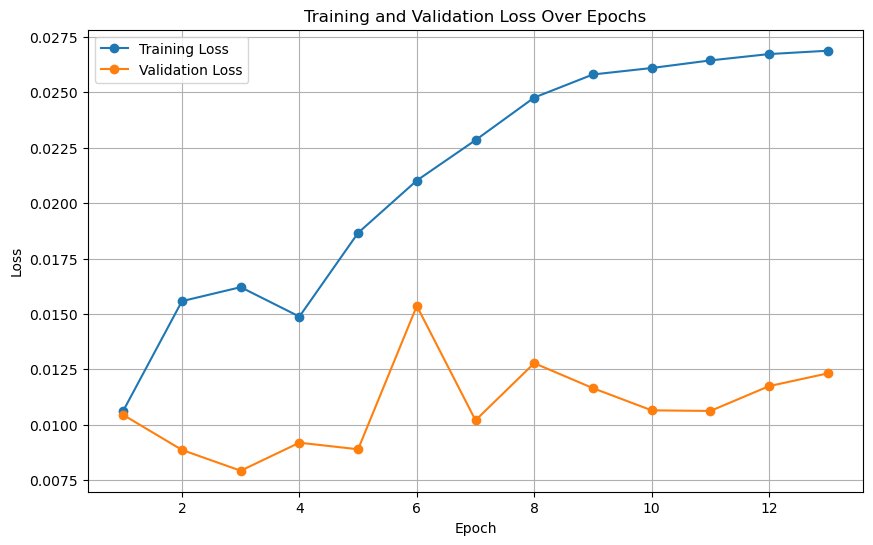

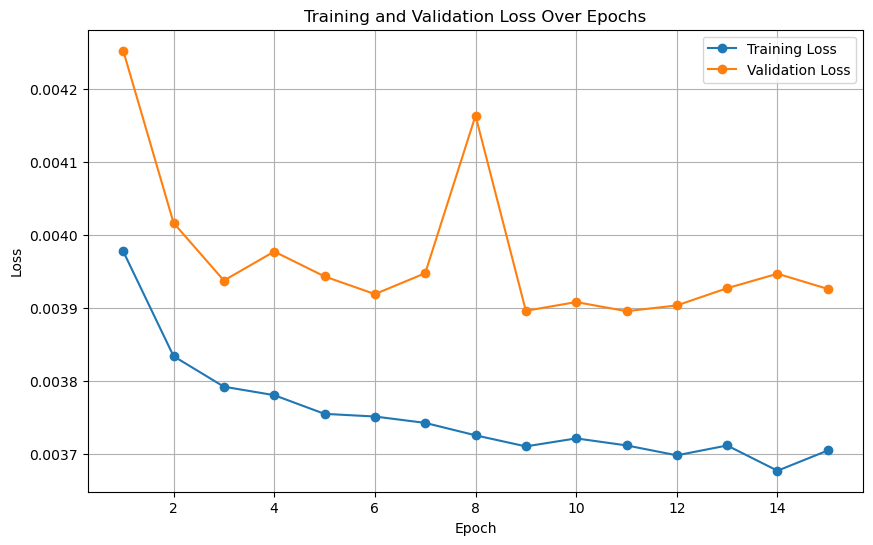

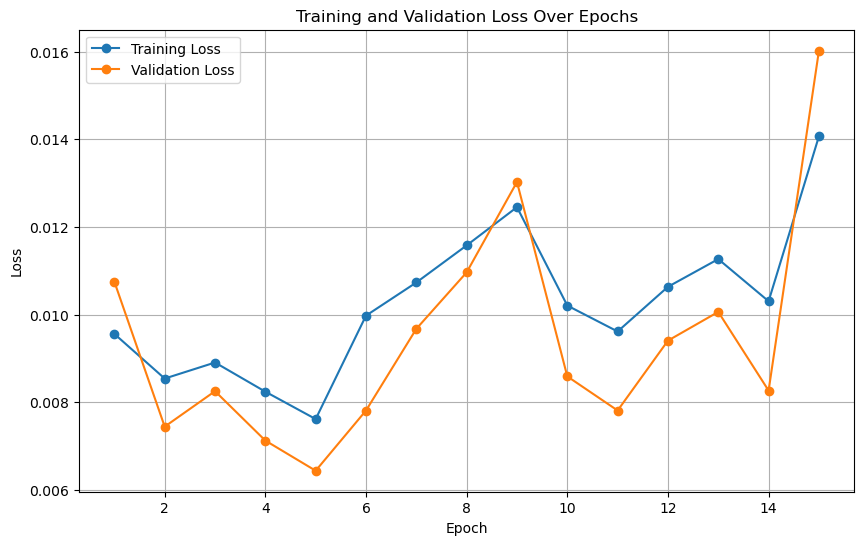

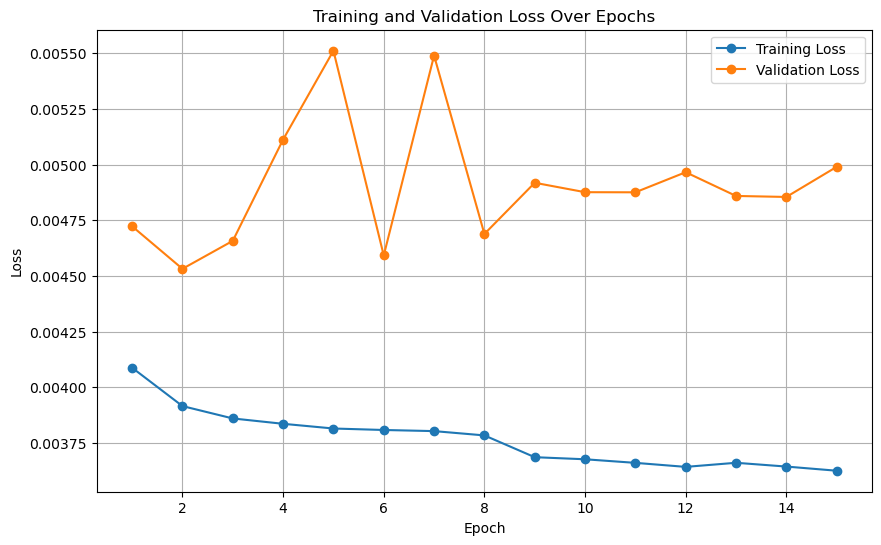

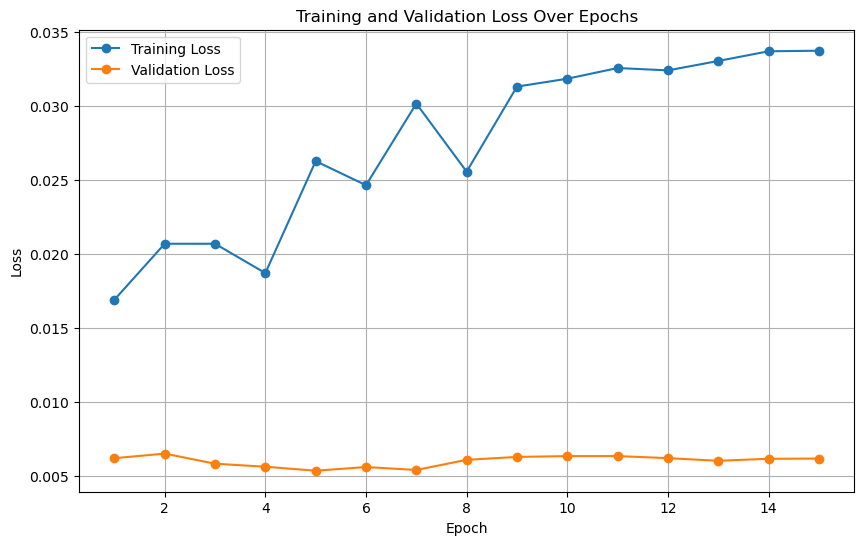

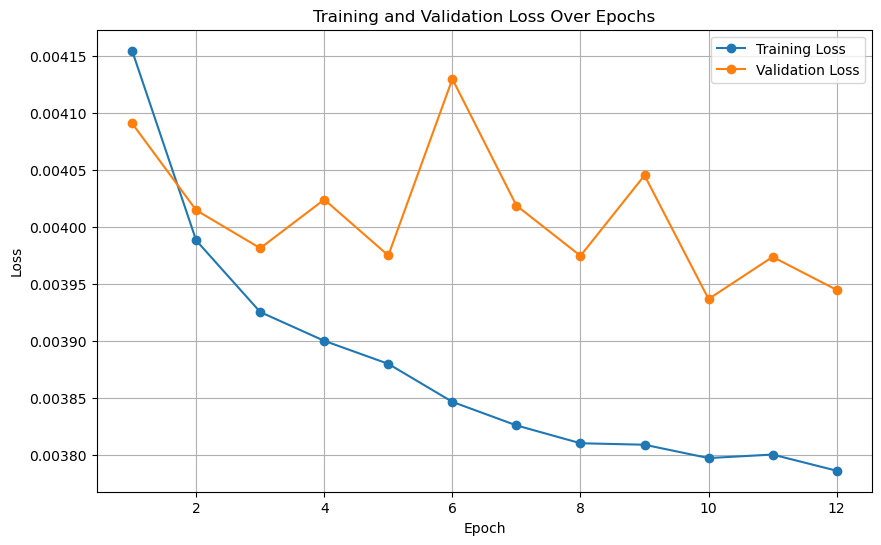

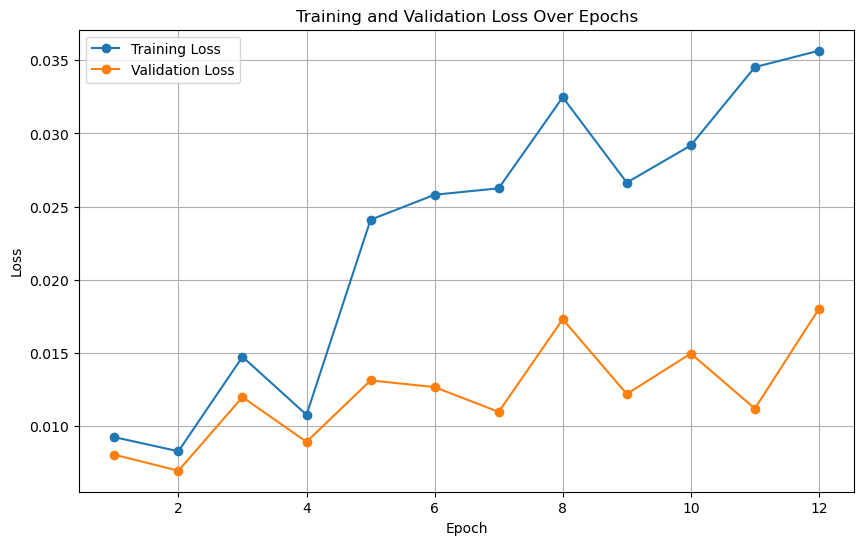

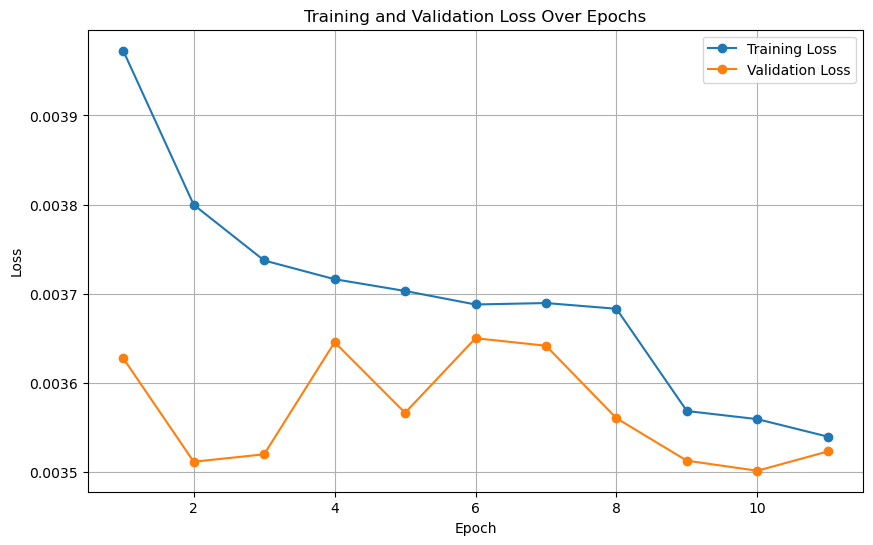

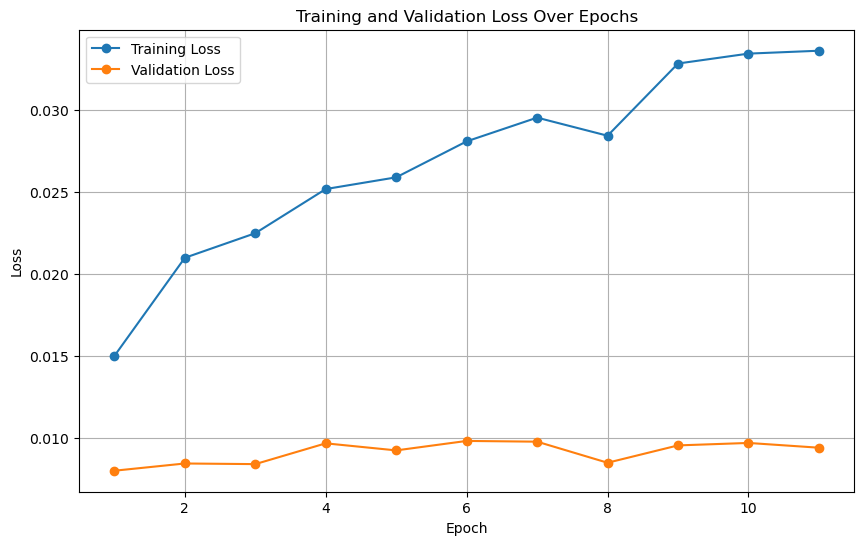

In [15]:
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV2_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

In [18]:
# Try Gamma=1.5

# CV2 on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 10 # number of cross validations
cv = 2 # hold out query only
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15/"
prefix = "CV2_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 1

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15/' is ready.
Data Split Method: CV2
220 of unique queries in total
22 queries held out for validation set
22 queries held out for test set
(2997316, 256)
(374901, 256)
(374643, 256)
Final test ratio of pairs: 0.09998852372386478
Final test:train ratio 0.11110544345290083
Using cuda device
[2025-07-04 20:59:10] Training started
Epoch 1/50: Train Loss: 0.0039, Val Loss: 0.0043
Epoch 1: Train AUPR=0.0177 AUROC=0.8484 | Val AUPR=0.0059 AUROC=0.7524
Epoch 2/50: Train Loss: 0.0037, Val Loss: 0.0042
Epoch 2: Train AUPR=0.0237 AUROC=0.8609 | Val AUPR=0.0082 AUROC=0.7970
Epoch 3/50: Train Loss: 0.0036, Val Loss: 0.0042
Epoch 3: Train AUPR=0.0259 AUROC=0.8638 | Val AUPR=0.0097 AUROC=0.7947
Epoch 4/50: Train Loss: 0.0036, Val Loss: 0.0042
Epoch 4: Train AUPR=0.0275 AUROC=0.8660 | Val AUPR=0.0079 AUROC=0.7895
Epoch 5/50: Train Loss: 0.0036, Val Loss: 0.0043
Epoch 5: Train AUPR=0.0295 AUROC=0.8671 | Val AUPR=

KeyboardInterrupt: 

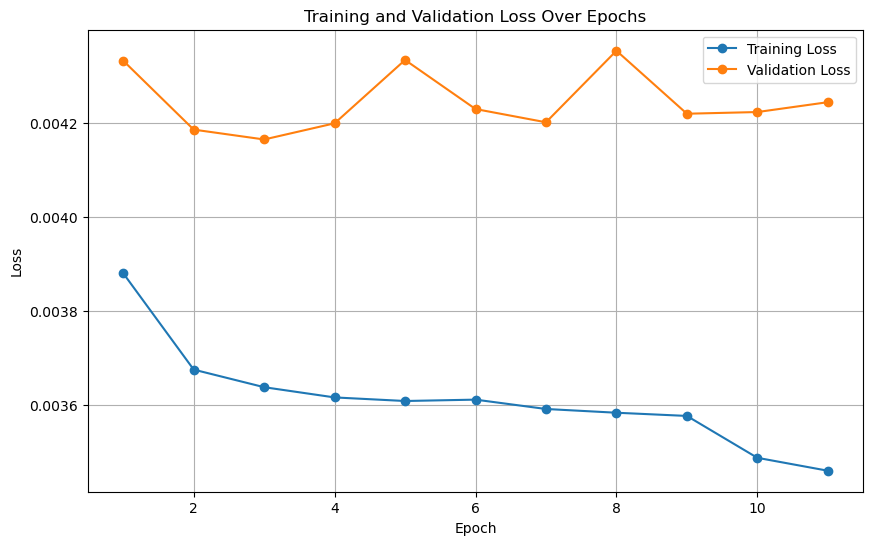

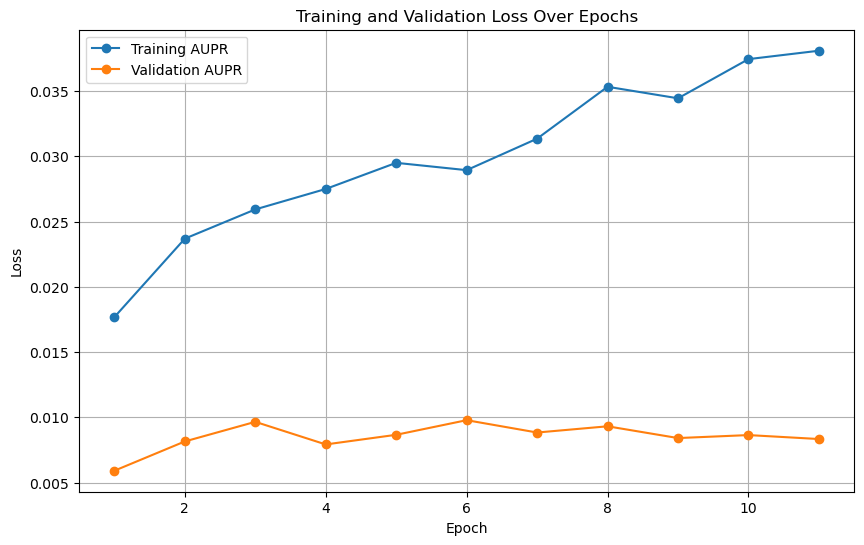

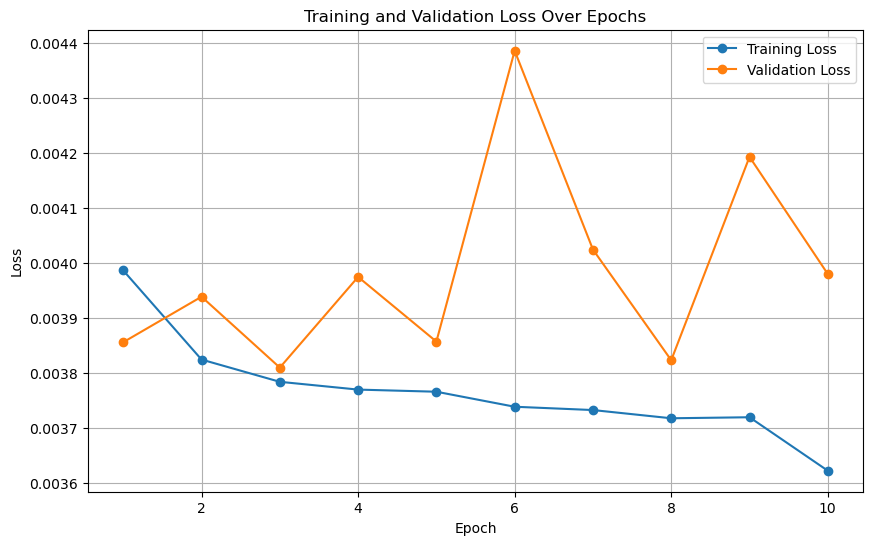

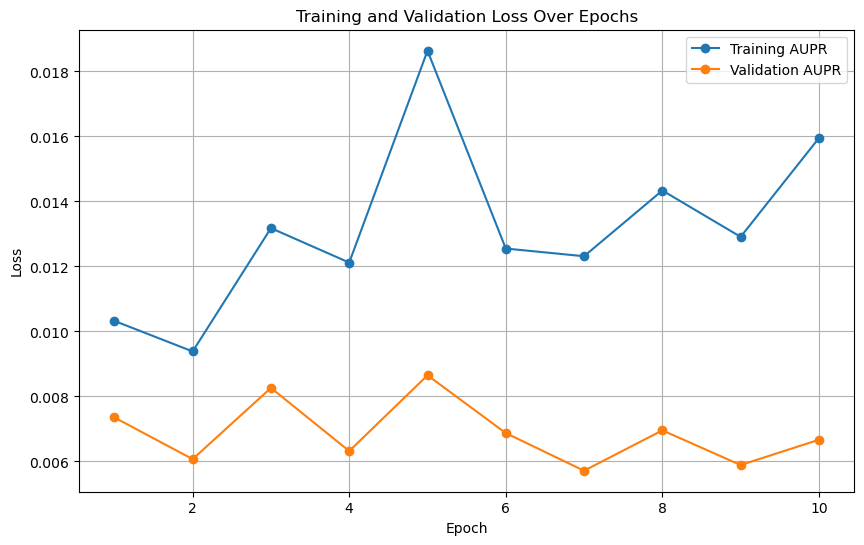

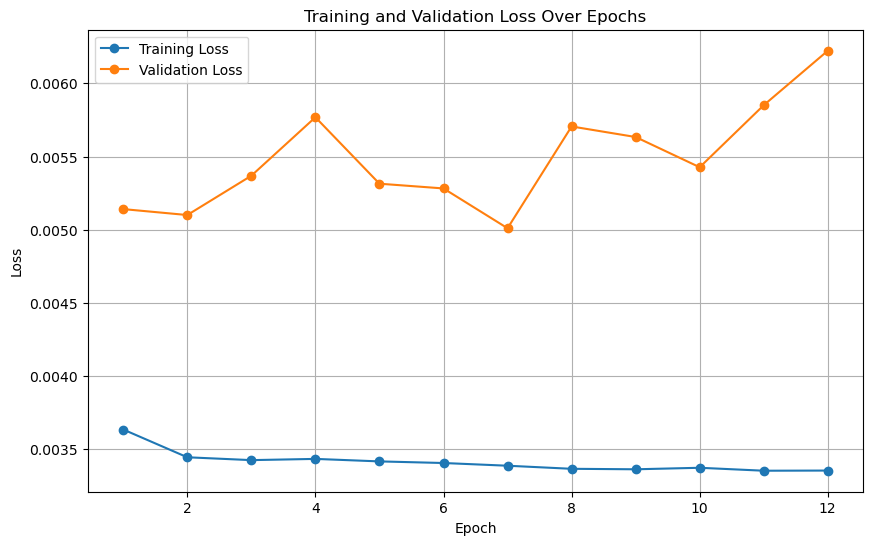

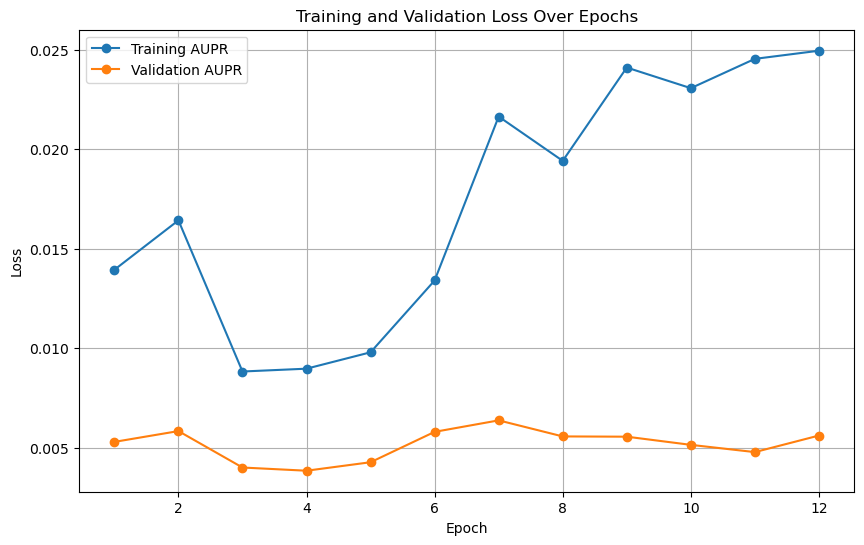

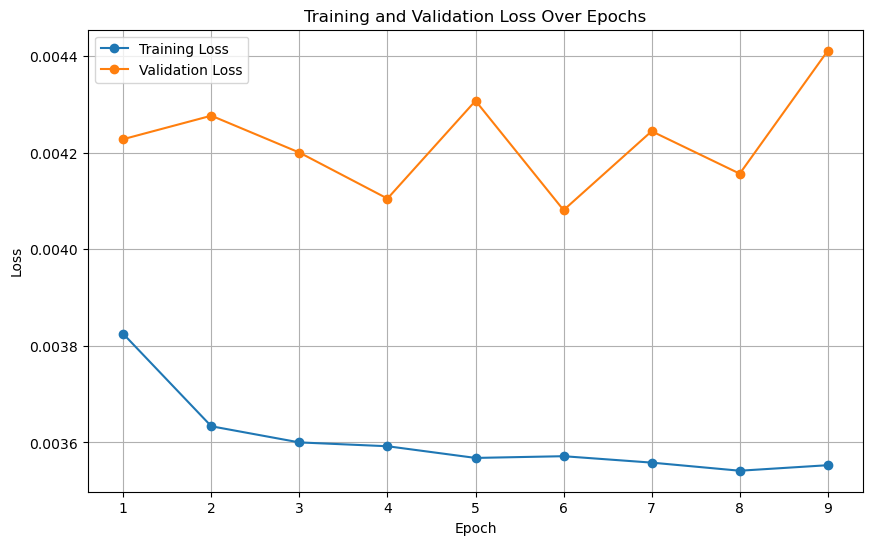

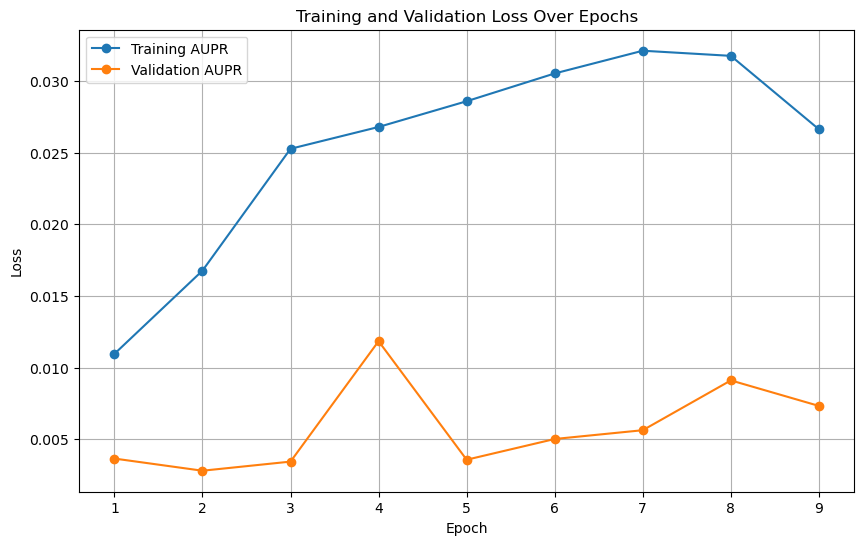

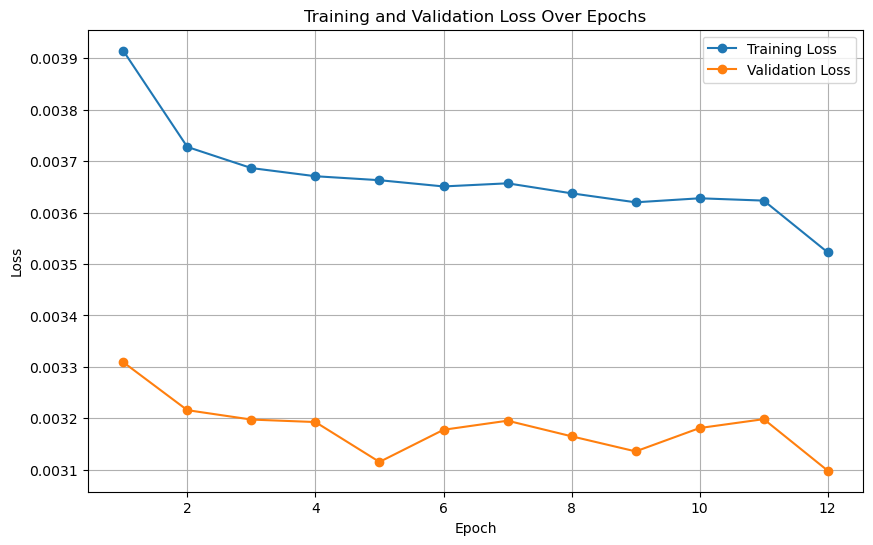

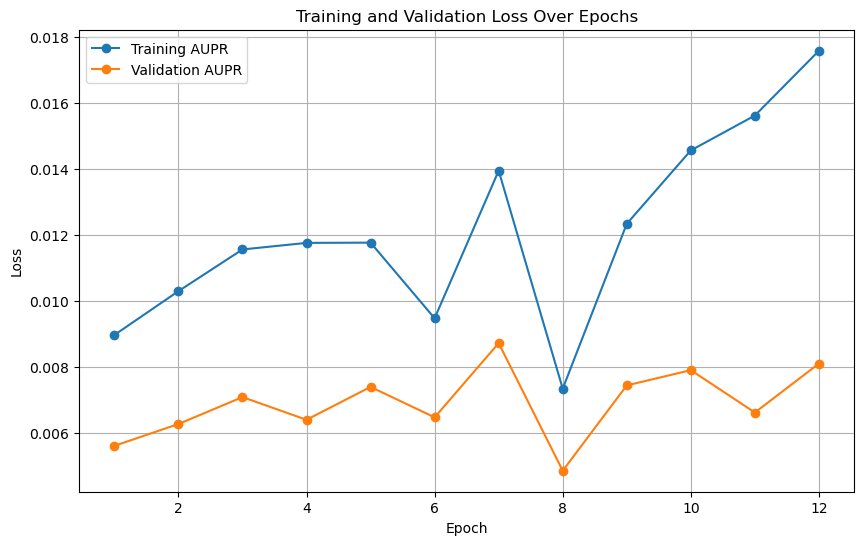

In [19]:
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV2_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

In [20]:
# From 5 folds
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

AUROC            0.808547
AUPR             0.026002
AP               0.008777
Recall@100       0.004145
Precision@100    0.026000
dtype: float64
AUROC            0.022195
AUPR             0.033909
AP               0.001365
Recall@100       0.002581
Precision@100    0.021909
dtype: float64


In [15]:
# Another 5 runs

# CV2 on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 5 # number of cross validations
cv = 2 # hold out query only
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15/"
prefix = "CV2_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 6

6
Directory '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15/' is ready.
Data Split Method: CV2
220 of unique queries in total
22 queries held out for validation set
22 queries held out for test set
(2997215, 256)
(374780, 256)
(374865, 256)
Final test ratio of pairs: 0.10004777333553963
Final test:train ratio 0.11116729140471163
Using cuda device
[2025-07-05 11:15:25] Training started
Epoch 1/50: Train Loss: 0.0037, Val Loss: 0.0043
Epoch 1: Train AUPR=0.0166 AUROC=0.8497 | Val AUPR=0.0177 AUROC=0.7838
Epoch 2/50: Train Loss: 0.0036, Val Loss: 0.0043
Epoch 2: Train AUPR=0.0226 AUROC=0.8596 | Val AUPR=0.0160 AUROC=0.7527
Epoch 3/50: Train Loss: 0.0035, Val Loss: 0.0043
Epoch 3: Train AUPR=0.0253 AUROC=0.8638 | Val AUPR=0.0148 AUROC=0.7644
Epoch 4/50: Train Loss: 0.0035, Val Loss: 0.0043
Epoch 4: Train AUPR=0.0232 AUROC=0.8639 | Val AUPR=0.0186 AUROC=0.7739
Epoch 5/50: Train Loss: 0.0035, Val Loss: 0.0045
Epoch 5: Train AUPR=0.0297 AUROC=0.8684 | Val AUPR=

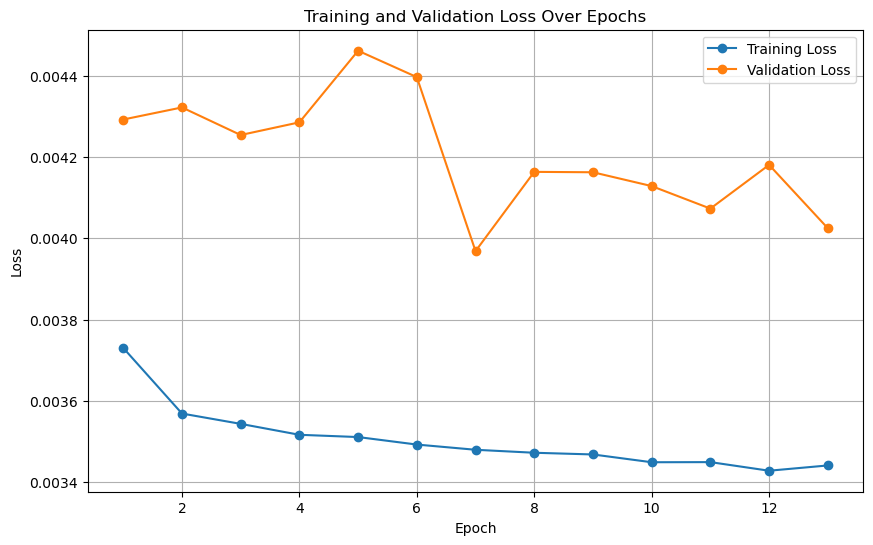

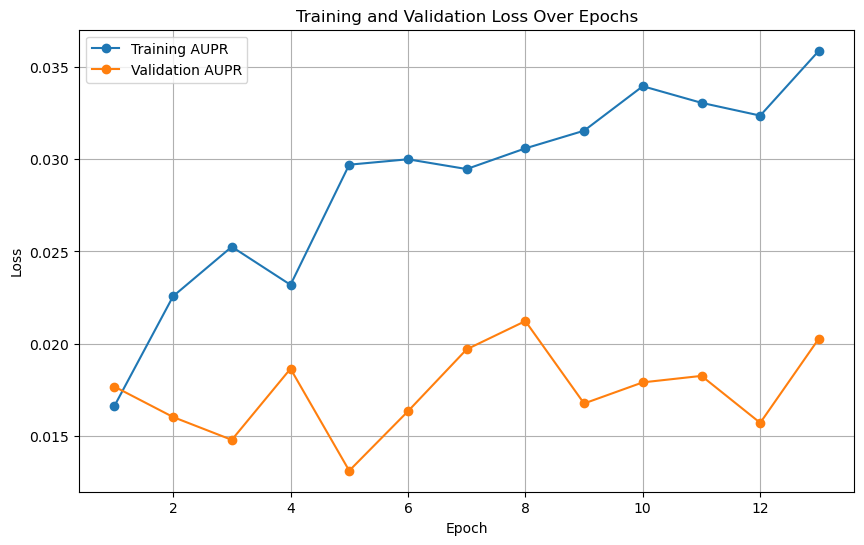

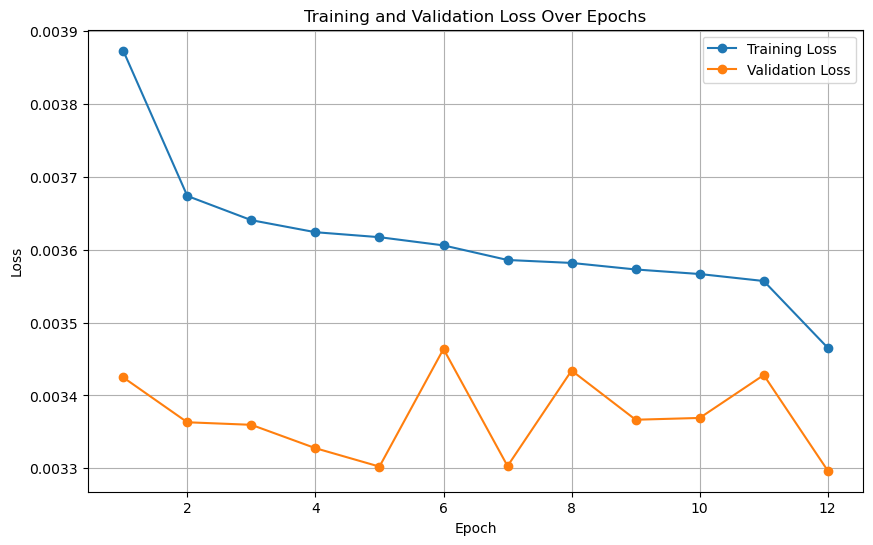

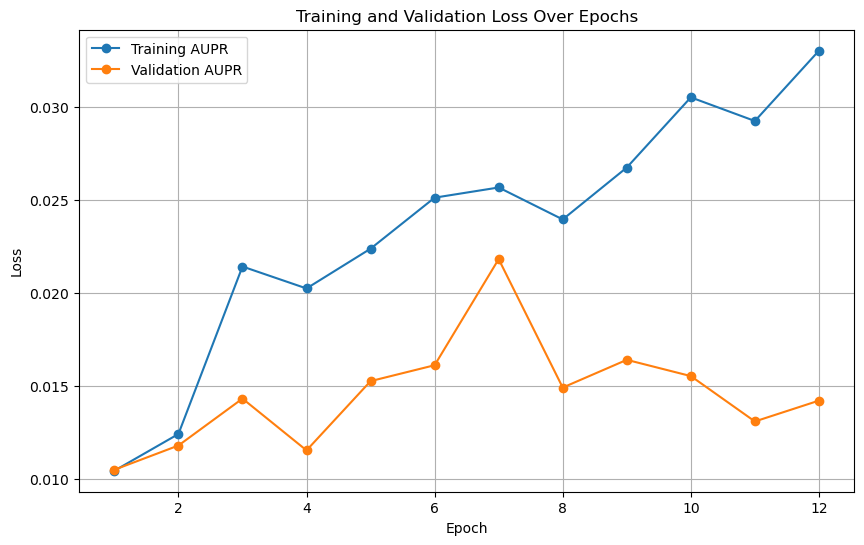

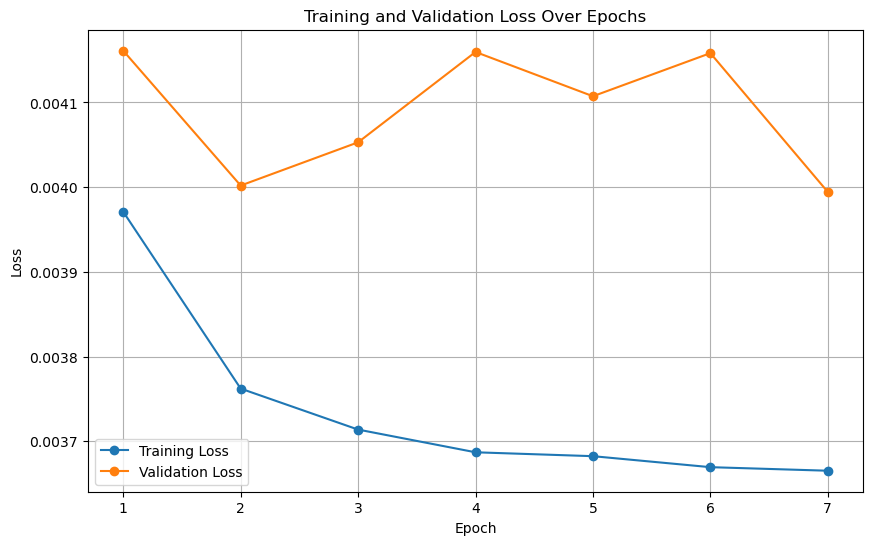

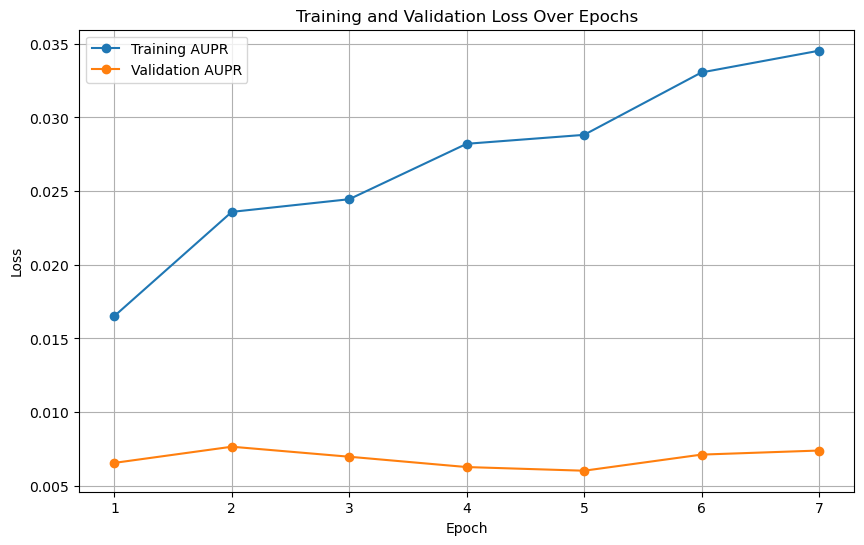

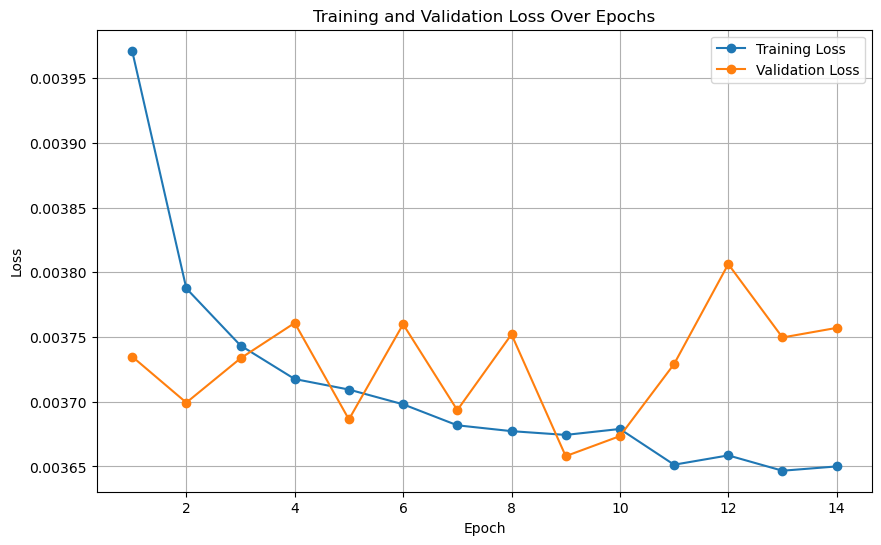

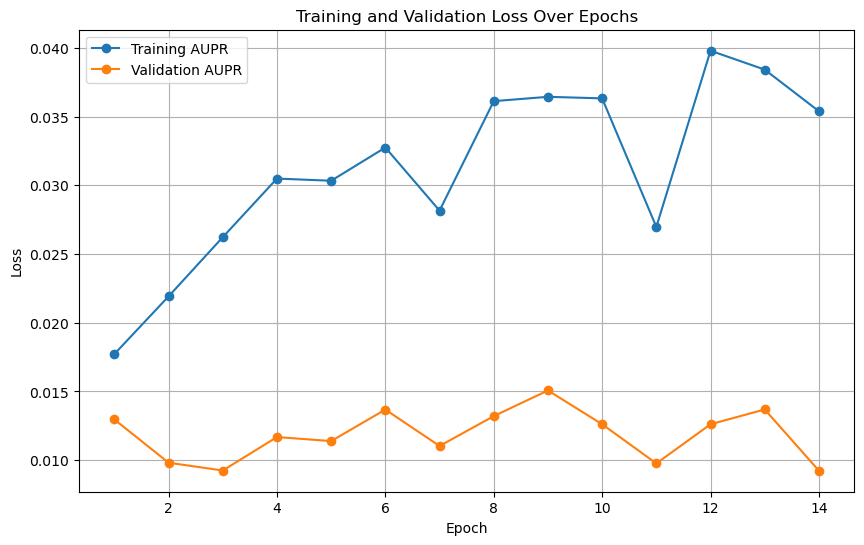

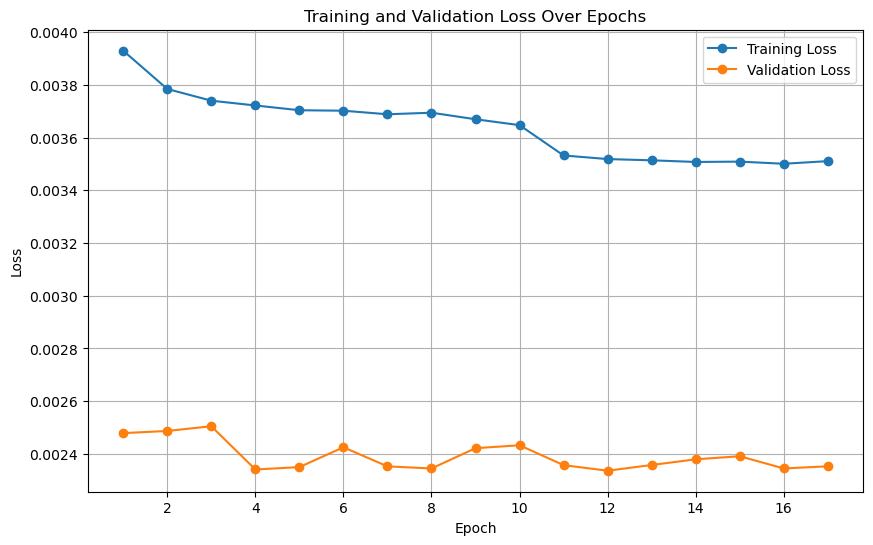

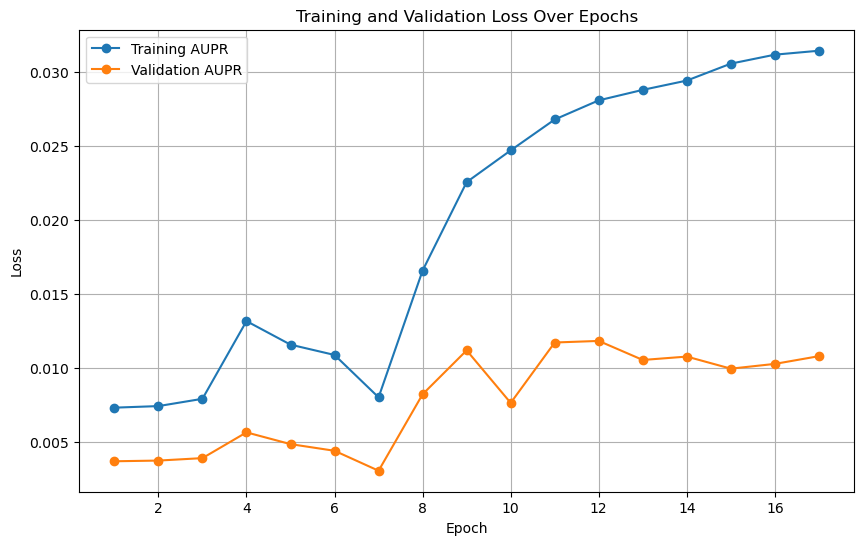

In [16]:
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV2_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

In [ ]:
# 07052025: Re-define CV2 query split to be 10 folds and iterate through all


In [21]:
for i in range(1, 11):
    print(i-1)
    print((i-2)%10)
    print()


0
9

1
0

2
1

3
2

4
3

5
4

6
5

7
6

8
7

9
8



In [27]:
# 10 split runs

# CV4(2) on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 10 # number of cross validations
cv = 4 # hold out query only - 10 folds
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15_10folds/"
prefix = "CV2_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 1

In [ ]:
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=1842, k_fold=i,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV2_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15_10folds/' is ready.
Data Split Method: CV4
220 unique queries in total
176 queries used for training set
22 queries held out for validation set
Val queries: ['GNPTG' 'PBRM1' 'SLCO4A1' 'LMNA' 'NF2' 'PTPN11' 'GANAB' 'CLPX' 'NDUFA2'
 'ATP5MG' 'ARMC5' 'NAA60' 'FASN' 'COQ7' 'OGA' 'GSK3B' 'STX4' 'SETDB1'
 'TOMM7' 'PELO' 'HDAC2' 'SIN3A']
22 queries held out for test set
Test queries: ['ANTXR1' 'EIF4H' 'NAA30' 'STAG1' 'NAGK' 'DDI2' 'VPS52' 'MAT2B' 'PDCD5'
 'ALG9' 'ATP9B' 'WRN' 'ARL1' 'EHMT2' 'DLAT' 'KDM5C' 'RER1' 'ACTB' 'PIK3CA'
 'TMEM126A' 'FASTKD3' 'RB1CC1']
Train set shape: (2997480, 256)
Validation set shape: (374679, 256)
Test set shape: (374701, 256)
Final test ratio of pairs: 0.10000400335214019
Final test:train ratio 0.11111532862559868
Using cuda device
[2025-07-05 15:48:28] Training started
Epoch 1/50: Train Loss: 0.0036, Val Loss: 0.0044
Epoch 1: Train AUPR=0.0107 AUROC=0.8384 | Val AUPR=0.00

In [24]:
# t-SNE visualize try
df_features = df_SL.iloc[:, 12:].dropna(axis=0, how='any')

In [25]:
df_features

,ko_0,ko_1,ko_2,ko_3,ko_4,ko_5,ko_6,ko_7,ko_8,ko_9,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
0,3.175312,-2.073136,-2.073136,-2.073136,-2.073136,2.836368,-2.073136,0.945784,-2.073136,5.775781,...,4.913545,-4.577069,-2.975184,0.219520,12.293355,-4.577069,-4.577069,-4.577069,8.642893,-4.577069
1,3.984911,-0.753604,-1.938399,-1.938399,-1.938399,-0.451993,-1.938399,-1.365817,-1.938399,1.279172,...,4.303340,-4.555482,-2.751121,-0.054748,12.947809,-4.555482,-4.555482,-4.555482,10.567736,-4.555482
2,8.501009,-3.012313,5.360662,-3.012313,-3.012313,-1.525907,-3.012313,-2.439730,-3.012313,6.431326,...,4.548736,-4.722307,-2.503048,-1.429313,12.398306,-4.722307,-4.722307,-4.722307,11.951158,-4.722307
3,-1.529302,-3.317969,-3.317969,-3.317969,-3.317969,5.599222,-3.317969,-1.831821,-3.317969,3.327886,...,8.235797,-6.877022,0.485464,-4.421445,20.778425,-6.877022,-6.877022,-6.877022,15.593998,-6.877022
4,1.250037,-0.429378,-3.019437,-3.019437,-3.019437,2.054880,-3.019437,-2.446854,-3.019437,3.496978,...,6.541844,-6.561955,-1.588224,-4.106378,19.115791,-6.561955,-6.561955,-6.561955,12.307260,-6.561955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3912774,5.198012,-2.023110,-2.023110,-2.023110,-2.023110,2.062033,-2.023110,2.276840,-2.023110,5.373183,...,-0.987153,-3.426391,-0.600135,3.363746,10.479098,-3.426391,-3.426391,-3.426391,9.282865,8.296420
3912775,3.627435,-1.837685,-1.948251,-1.948251,-1.948251,3.417739,-1.948251,1.264808,-1.948251,4.628111,...,0.054278,-2.504334,0.321922,1.532488,6.988276,-2.504334,-2.504334,-2.504334,2.574751,-1.657835
3912776,4.771541,-2.301700,-2.301700,-2.301700,-2.301700,0.756266,-2.301700,0.041070,-2.301700,6.832438,...,5.589154,-4.271820,2.370458,-2.886664,5.771198,-4.271820,-4.271820,-4.271820,7.560047,-4.271820
3912777,5.129929,-1.842544,-1.842544,-1.842544,-1.842544,1.706724,-1.842544,1.456023,-1.842544,3.193419,...,0.022988,-2.610372,0.215884,2.645627,6.473591,-2.610372,-2.610372,-2.610372,3.664232,-2.610372


In [19]:
df_SL.columns[12:]

Index(['ko_0', 'ko_1', 'ko_2', 'ko_3', 'ko_4', 'ko_5', 'ko_6', 'ko_7', 'ko_8',
       'ko_9',
       ...
       'exp_118', 'exp_119', 'exp_120', 'exp_121', 'exp_122', 'exp_123',
       'exp_124', 'exp_125', 'exp_126', 'exp_127'],
      dtype='object', length=256)

PCA result shape: (20000, 50)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20000 samples in 0.001s...
[t-SNE] Computed neighbors for 20000 samples in 0.656s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20000
[t-SNE] Computed conditional probabilities for sample 2000 / 20000
[t-SNE] Computed conditional probabilities for sample 3000 / 20000
[t-SNE] Computed conditional probabilities for sample 4000 / 20000
[t-SNE] Computed conditional probabilities for sample 5000 / 20000
[t-SNE] Computed conditional probabilities for sample 6000 / 20000
[t-SNE] Computed conditional probabilities for sample 7000 / 20000
[t-SNE] Computed conditional probabilities for sample 8000 / 20000
[t-SNE] Computed conditional probabilities for sample 9000 / 20000
[t-SNE] Computed conditional probabilities for sample 10000 / 20000
[t-SNE] Computed conditional probabilities for sample 11000 / 20000
[t-SNE] Computed conditional probabilities for sample 12000 / 20000
[t-SNE] Computed con

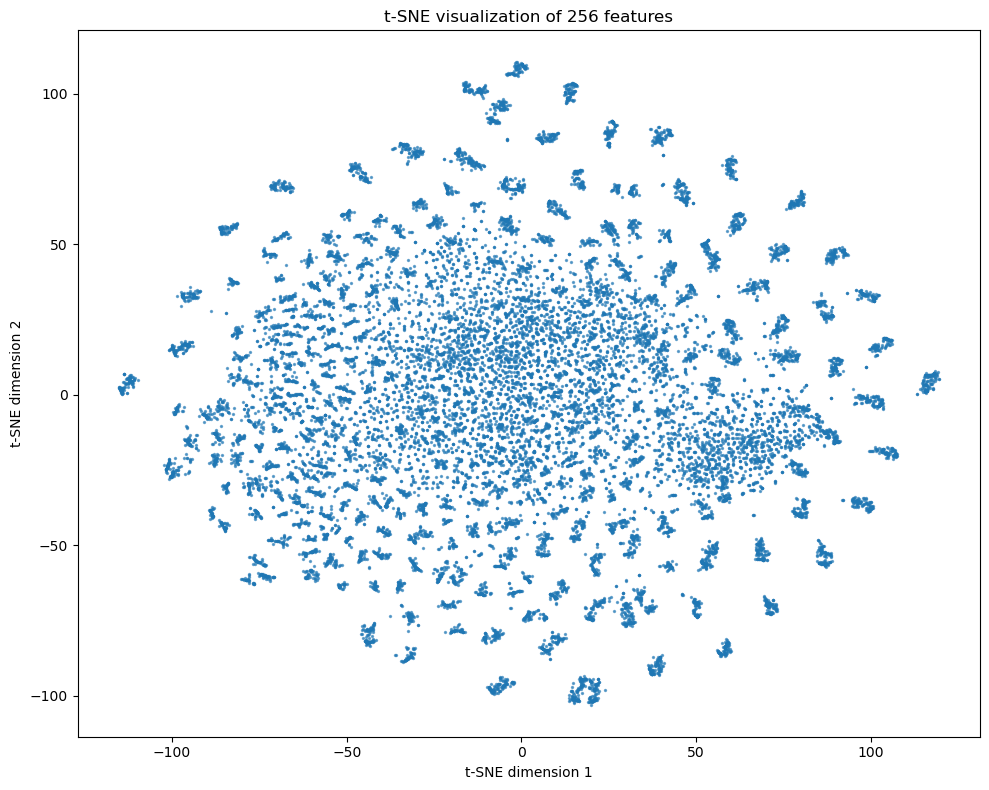

In [26]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Suppose your DataFrame is called df_features
# shape = (4,000,000, 256)

# Step 1: Subsample
n_samples = 20000  # You can adjust this
df_sub = df_features.sample(n=n_samples, random_state=42)

# Step 2: Optionally reduce dimensions with PCA first
pca = PCA(n_components=50, random_state=42)
pca_result = pca.fit_transform(df_sub)

print(f"PCA result shape: {pca_result.shape}")

# Step 3: Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,        # Can try 10–50 depending on data
    n_iter=1000,
    random_state=42,
    verbose=1
)
tsne_result = tsne.fit_transform(pca_result)

print(f"t-SNE result shape: {tsne_result.shape}")

# Step 4: Plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=2, alpha=0.6)
plt.title("t-SNE visualization of 256 features")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.008s...
[t-SNE] Computed neighbors for 10000 samples in 0.505s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 11.473977
[t-SNE] KL divergence after 250 iterations with early exaggeration: 88.894234
[t-SNE] KL divergence after 1000 iterations: 1.584496


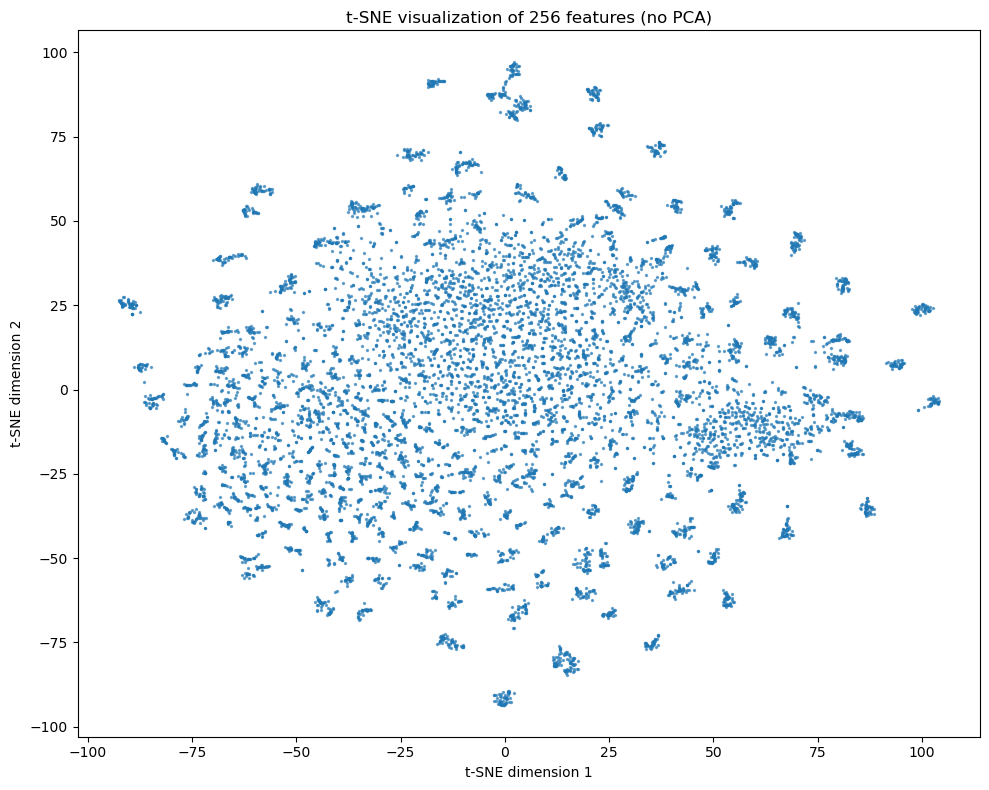

In [27]:
# Direct t-SNE
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Assume df_features is your DataFrame with 256 columns

# Step 1: Subsample
n_samples = 10000
df_sub = df_features.sample(n=n_samples, random_state=42)

# Step 2: t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    verbose=1
)
tsne_result = tsne.fit_transform(df_sub)

# Step 3: Plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=2, alpha=0.6)
plt.title("t-SNE visualization of 256 features (no PCA)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

<Axes: >

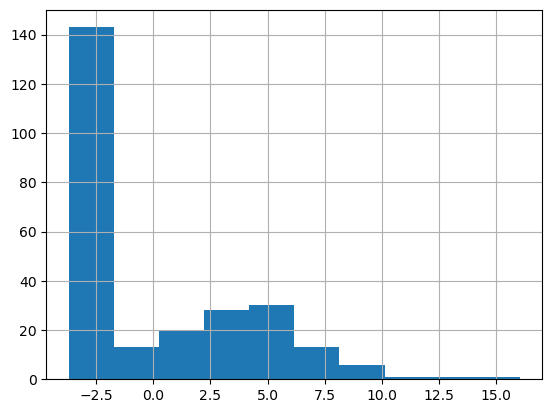

In [30]:
df_sub.mean().hist()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.008s...
[t-SNE] Computed neighbors for 10000 samples in 0.517s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.442433
[t-SNE] KL divergence after 250 iterations with early exaggeration: 89.798378
[t-SNE] KL divergence after 1000 iterations: 1.827147


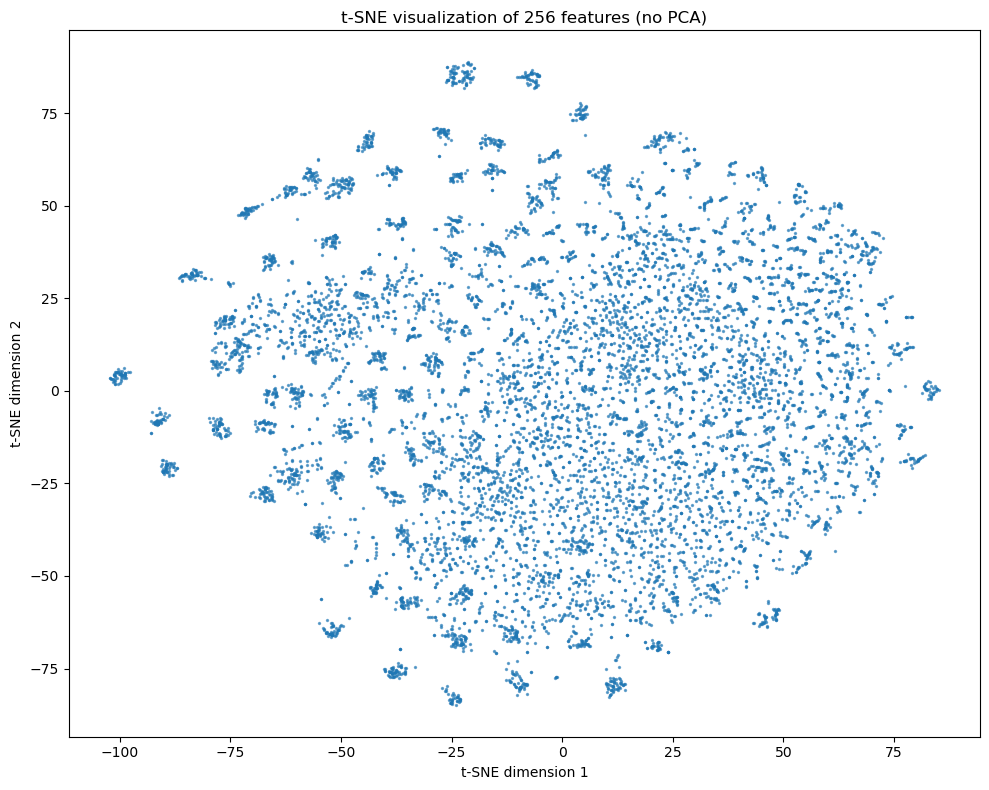

In [31]:
from sklearn.preprocessing import StandardScaler
df_sub_scaled = StandardScaler().fit_transform(df_sub)

# Step 2: t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    verbose=1
)
tsne_result = tsne.fit_transform(df_sub_scaled)

# Step 3: Plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=2, alpha=0.6)
plt.title("t-SNE visualization of 256 features (no PCA)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

In [34]:
# Read the output tsv and check who are the highest predictions

df_SL_output = create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/output/",
                giv_dir='cv2_24Q4/AE_ReLU/ReLU128_5L_f_a075_g15_10folds/', iter_num=11)

CV2_811_GIV_NN_LR1e2_50e_p5_d01_1.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_2.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_3.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_4.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_5.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_6.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_7.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_8.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_9.tsv
CV2_811_GIV_NN_LR1e2_50e_p5_d01_10.tsv
(3746860, 14)


In [35]:
df_SL_output

,Unnamed: 0,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,predict_proba
0,3,A1BG,ACTB,-0.012187,0.991106,NaN,NaN,0,0,0,0,0,0,0.029353
1,10,A1BG,ALG9,0.196221,0.677578,NaN,NaN,0,0,0,0,0,0,0.031228
2,12,A1BG,ANTXR1,-0.025021,0.864406,NaN,NaN,0,0,0,0,0,0,0.016310
3,18,A1BG,ARL1,0.118938,0.878152,NaN,NaN,0,0,0,0,0,0,0.037052
4,25,A1BG,ATP9B,0.010594,0.990258,NaN,NaN,0,0,0,0,0,0,0.032086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3746855,3868195,ZYG11A,TOMM7,-0.100884,0.537242,NaN,NaN,0,0,0,0,0,0,0.047516
3746856,3868196,ZYG11B,TOMM7,-0.206732,0.535115,NaN,NaN,0,0,0,0,0,0,0.087999
3746857,3868197,ZYX,TOMM7,-0.019727,0.998253,NaN,NaN,0,0,0,0,0,0,0.060716
3746858,3868198,ZZEF1,TOMM7,-0.056863,0.663706,NaN,NaN,0,0,0,0,0,0,0.095690


In [36]:
df_SL_output.sort_values(by='predict_proba', ascending=False)

,Unnamed: 0,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,predict_proba
3368531,3892906,UNC50,VPS54,-1.404955,6.550392e-12,negative,negative,1,1,0,1,1,0,0.345022
3068193,566811,ASNA1,VPS54,-0.061886,8.430209e-01,NaN,NaN,0,0,0,0,0,0,0.344247
3335766,3572332,RAB18,VPS54,-0.406010,6.791924e-01,NaN,NaN,0,0,0,0,0,0,0.334666
3136314,1458637,COG7,VPS54,-0.761148,4.382797e-03,negative,negative,1,1,0,1,1,0,0.308765
3148578,1667752,DERL2,VPS54,-0.129139,5.053910e-01,NaN,NaN,0,0,0,0,0,0,0.301404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1239128,1354838,WFDC2,CDKN2B,0.106477,6.956144e-01,NaN,NaN,0,0,0,0,0,0,0.000539
2377871,1090016,WFDC2,C1orf115,-0.028907,9.463251e-01,NaN,NaN,0,0,0,0,0,0,0.000507
1158771,812927,IFI27,BCL2,-0.239812,3.002676e-01,NaN,NaN,0,0,0,0,0,0,0.000499
1229705,1345111,IFI27,CDKN2B,-0.048131,9.893365e-01,NaN,NaN,0,0,0,0,0,0,0.000410


In [38]:
plot_ROC_PR(all_labels=df_SL_output['GI_stringent_Type2'], all_probs=df_SL_output['predict_proba'], plt_direc=None, K=100)

ROC AUC: 0.7558
PRC AUC: 0.0086
Average Precision: 0.0086
Recall@100: 0.0027
Precision@100: 0.1800


[0.7557707212107992,
 0.008557655894360503,
 0.008591333382830591,
 0.0027359781121751026,
 0.18]

In [39]:
plot_ROC_PR(all_labels=df_SL_output['GI_standard_Type2'], all_probs=df_SL_output['predict_proba'], plt_direc=None, K=100)

ROC AUC: 0.6345
PRC AUC: 0.0231
Average Precision: 0.0231
Recall@100: 0.0005
Precision@100: 0.2300


[0.6345314946982453,
 0.023055097852386085,
 0.02305118098341838,
 0.0005148408470251153,
 0.23]

<Axes: >

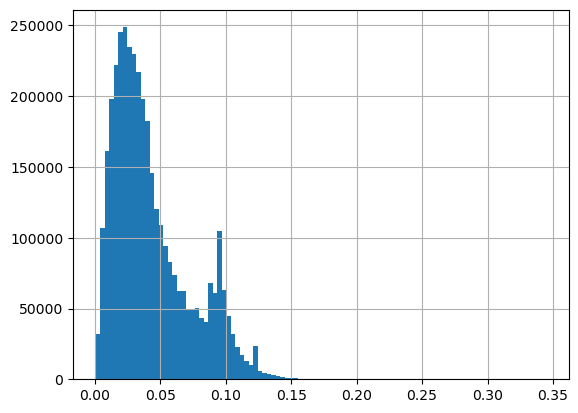

In [40]:
df_SL_output['predict_proba'].hist(bins=100)

In [41]:
df_SL_output['predict_proba'].nlargest(1000)

3368531    0.345022
3068193    0.344247
3335766    0.334666
3136314    0.308765
3148578    0.301404
             ...   
3289563    0.173567
3358581    0.173560
521964     0.173551
3136076    0.173550
515652     0.173493
Name: predict_proba, Length: 1000, dtype: float64

In [44]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:1000]['Query'].unique()

array(['VPS54', 'ARF1', 'ARID2', 'CDKN2A', 'GCLM', 'C1orf112', 'STAG2',
       'GSK3A', 'RER1', 'MGAT1', 'WNK1', 'VPS52', 'SGF29', 'SREBF2',
       'EXO1', 'PIGA', 'ARL1', 'TSC22D2', 'PTAR1', 'ALG9', 'FANCG',
       'ARID1A', 'SP1', 'LCMT1', 'ADAR', 'RICTOR', 'ITGAV', 'DDI2',
       'C12orf49', 'KEAP1', 'KDM5C', 'SLC16A1', 'ABCC1', 'TAZ', 'SLC35A1',
       'FITM2'], dtype=object)

In [46]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:1000]['Query'].unique().shape

(36,)

In [51]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:1000]['Gene'].unique()

array(['UNC50', 'ASNA1', 'RAB18', 'COG7', 'DERL2', 'TMED10', 'DPM1',
       'GET4', 'RAB10', 'DNAJC9', 'UBE2G2', 'COG3', 'TBC1D20', 'INTS6',
       'COG5', 'COG1', 'TM9SF3', 'SYVN1', 'TMED2', 'TRAPPC2L', 'MARCH5',
       'ATP6V0E1', 'TRAPPC13', 'KCTD10', 'PI4KB', 'TSSC1', 'SEC31A',
       'MON2', 'IER3IP1', 'RAB1A', 'CLTC', 'SLC35A2', 'TMEM41B', 'VPS45',
       'RAB7A', 'DERL1', 'TMEM208', 'VPS16', 'WRB', 'YIPF5', 'AUP1',
       'RER1', 'VPS41', 'VPS33A', 'SMARCB1', 'MLST8', 'JTB', 'SLC39A9',
       'CSNK2A1', 'ARL1', 'RAB5C', 'DDX19A', 'EMC6', 'SH3GL1', 'ARPC4',
       'CARM1', 'SLC33A1', 'AZIN1', 'VPS53', 'VPS29', 'VDAC2', 'GDI2',
       'ARF1', 'SQLE', 'CNIH4', 'ALG5', 'MPDU1', 'UGP2', 'SLC25A1',
       'PMM2', 'EMC1', 'SLC11A2', 'FASN', 'NBAS', 'ATL2', 'VPS52',
       'MARCH6', 'KDSR', 'COG6', 'COG4', 'HECTD1', 'DDRGK1', 'VPS51',
       'AP1G1', 'YTHDF2', 'TFG', 'IDI1', 'GLRX3', 'FDFT1', 'EIF3K',
       'SAR1A', 'MCL1', 'AKT2', 'FAF2', 'PIK3C3', 'SCYL1', 'NAPG', 'TUBB',
       'SUR

In [52]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:1000]['Gene'].unique().shape

(740,)

In [45]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:10000]['Query'].unique()

array(['VPS54', 'ARF1', 'ARID2', 'CDKN2A', 'GCLM', 'C1orf112', 'STAG2',
       'GSK3A', 'RER1', 'MGAT1', 'WNK1', 'VPS52', 'SGF29', 'SREBF2',
       'EXO1', 'PIGA', 'ARL1', 'TSC22D2', 'PTAR1', 'ALG9', 'FANCG',
       'ARID1A', 'SP1', 'LCMT1', 'ADAR', 'RICTOR', 'ITGAV', 'DDI2',
       'C12orf49', 'KEAP1', 'KDM5C', 'SLC16A1', 'ABCC1', 'TAZ', 'SLC35A1',
       'FITM2', 'ACACA', 'TRIM37', 'RGP1', 'KLF10', 'ALG12', 'WASL',
       'FLCN', 'RB1CC1', 'WASHC5', 'HGS', 'USP15', 'GOT1', 'USP14',
       'BMPR1A', 'PCSK9', 'PTPN11', 'EMC2', 'STAG1', 'VDAC1', 'NAGK',
       'UBE2H', 'TAF5L', 'EHMT2', 'GFPT1', 'BRD1', 'ALG8', 'PBRM1',
       'TAPT1', 'LDHA', 'PGP', 'ATP9B', 'DLAT', 'ROCK2', 'RHOA', 'AKT1',
       'TUBB', 'SREBF1', 'COQ9', 'LIG4', 'HEATR5B', 'C5orf34', 'TIMM8A',
       'OGA', 'BRD4', 'HDAC3', 'ATG9A', 'CLPX', 'KAT7', 'ITGB1', 'SETDB1',
       'TMEM126A', 'SLC1A5', 'PARP1', 'NRBP1', 'FOXRED1', 'WRN', 'PRKAB1',
       'NAA30', 'FBXO6', 'ANTXR1', 'PIK3CA', 'TET1', 'HDAC2', 'GANAB',
      

In [48]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:10000]['Query'].unique().shape

(104,)

In [49]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:100000]['Query'].unique()

array(['VPS54', 'ARF1', 'ARID2', 'CDKN2A', 'GCLM', 'C1orf112', 'STAG2',
       'GSK3A', 'RER1', 'MGAT1', 'WNK1', 'VPS52', 'SGF29', 'SREBF2',
       'EXO1', 'PIGA', 'ARL1', 'TSC22D2', 'PTAR1', 'ALG9', 'FANCG',
       'ARID1A', 'SP1', 'LCMT1', 'ADAR', 'RICTOR', 'ITGAV', 'DDI2',
       'C12orf49', 'KEAP1', 'KDM5C', 'SLC16A1', 'ABCC1', 'TAZ', 'SLC35A1',
       'FITM2', 'ACACA', 'TRIM37', 'RGP1', 'KLF10', 'ALG12', 'WASL',
       'FLCN', 'RB1CC1', 'WASHC5', 'HGS', 'USP15', 'GOT1', 'USP14',
       'BMPR1A', 'PCSK9', 'PTPN11', 'EMC2', 'STAG1', 'VDAC1', 'NAGK',
       'UBE2H', 'TAF5L', 'EHMT2', 'GFPT1', 'BRD1', 'ALG8', 'PBRM1',
       'TAPT1', 'LDHA', 'PGP', 'ATP9B', 'DLAT', 'ROCK2', 'RHOA', 'AKT1',
       'TUBB', 'SREBF1', 'COQ9', 'LIG4', 'HEATR5B', 'C5orf34', 'TIMM8A',
       'OGA', 'BRD4', 'HDAC3', 'ATG9A', 'CLPX', 'KAT7', 'ITGB1', 'SETDB1',
       'TMEM126A', 'SLC1A5', 'PARP1', 'NRBP1', 'FOXRED1', 'WRN', 'PRKAB1',
       'NAA30', 'FBXO6', 'ANTXR1', 'PIK3CA', 'TET1', 'HDAC2', 'GANAB',
      

In [50]:
df_SL_output.sort_values(by='predict_proba', ascending=False).iloc[:100000]['Query'].unique().shape

(179,)